---
# Production Code: Retrieval, Reflection & Generation Module

This section implements the **Retrieval**, **Self-Reflection**, and **Generation** parts of the team's workflow.

## Team Workflow Integration

```
┌─────────────────────────────────────────────────────────────────────────┐
│                        FULL LANGGRAPH PIPELINE                          │
├─────────────────────────────────────────────────────────────────────────┤
│  [Chunking & Indexing]  →  Teammate's embeddings work                   │
│           ↓                                                             │
│  [Query Translation]    →  Pre-processing, compression                  │
│           ↓                                                             │
│  [Routing]              →  Route 0: Irrelevant → Template               │
│                            Route 1: Generic → Company JSON              │
│                            Route 2: Product → THIS MODULE               │
│           ↓                                                             │
│  [Query Construction]   →  Self-query, metadata filters                 │
│           ↓                                                             │
│  ┌─────────────────────────────────────────────────────────────────┐    │
│  │  THIS MODULE: Retrieval & Reflection                            │    │
│  │  • Hybrid retrieval (BM25 + Semantic) with metadata filtering   │    │
│  │  • Query Router (adaptive strategy selection)                   │    │
│  │  • Self-reflection: single query → if fails → RAG Fusion        │    │
│  │  • Light LLM for retrieval, Good LLM for reflection             │    │
│  └─────────────────────────────────────────────────────────────────┘    │
│           ↓                                                             │
│  [Generation]           →  Chat history + Persona (Teammate)            │
└─────────────────────────────────────────────────────────────────────────┘
```

## Input (from Query Construction node)
- `query`: The user's query (possibly translated/compressed)
- `metadata_filters`: Extracted metadata filters from self-query retrieval
- `route`: Should be "product" (Route 2) when reaching this module

## Output
- `response`: Generated answer from Good LLM
- `retrieved_docs`: List of relevant documents used
- `retrieval_status`: "success" | "no_relevant_docs" | "fusion_used"
- `generation_status`: "success" | "no_context" | "error"
- `sources`: Product sources cited in response


# Dependencies and Imports

In [ ]:
## Dependencies

%pip install langgraph rank-bm25 python-dotenv
%pip install langchain-core langchain-community langchain-groq langchain-openai langchain-ollama
%pip install langchain-huggingface langchain-chroma chromadb

%pip -q install "huggingface-hub>=0.33.4,<1.0.0"
%pip -q install "sentence-transformers>=2.2.0,<3.0.0"
%pip -q install "langchain-huggingface>=0.1.0"


In [2]:
# =============================================================================
# CONSOLIDATED IMPORTS - All dependencies in one place
# =============================================================================

from __future__ import annotations

# Standard Library
import os
import re
import time
import json
import string
import getpass
import ast
from pathlib import Path
from enum import Enum
from dataclasses import dataclass
from typing import Literal, Iterable, TypedDict, Optional, Any, Dict, List, Tuple
from collections import Counter

# Third-party: Data & ML
import numpy as np
import pandas as pd

# Third-party: LangChain Core
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_core.documents import Document

# Third-party: LangChain Components
from langchain_community.document_loaders import CSVLoader
from langchain_huggingface import HuggingFaceEmbeddings, ChatHuggingFace, HuggingFaceEndpoint
from langchain_chroma import Chroma

# Third-party: Retrieval & RAG
from rank_bm25 import BM25Okapi

# Third-party: LLM Providers (imported only when needed in _build_llm)
# - langchain_groq.ChatGroq
# - langchain_openai.ChatOpenAI
# - langchain_ollama.ChatOllama

# Third-party: LangGraph
from langgraph.graph import StateGraph, START, END

# Environment
from dotenv import load_dotenv

# Load environment variables
load_dotenv(override=True)

print("✅ All imports loaded successfully")


✅ All imports loaded successfully


In [421]:

# =============================================================================
# LLM FACTORY (Light + Good LLMs)
# =============================================================================
# Team Pattern: Factory design for LLMs via .env file
# - Light LLM: For retrieval operations (cheaper, faster)
# - Good LLM: For reflection/grading (more capable)
# =============================================================================

@dataclass
class LLMConfig:
    provider: str
    model: str


def _build_llm(cfg: LLMConfig):
    """
    Factory method to build LLM from config.
    Supports: Groq, OpenAI, Ollama, HuggingFace

    Team Note: Ollama recommended for local deployment with Llama/Qwen.
    """
    provider = (cfg.provider or "").lower().strip()

    if provider == "groq":
        from langchain_groq import ChatGroq
        return ChatGroq(model=cfg.model, temperature=0.0)

    if provider == "openai":
        from langchain_openai import ChatOpenAI
        return ChatOpenAI(model=cfg.model, temperature=0.0)

    if provider == "ollama":
        from langchain_ollama import ChatOllama
        base_url = os.environ.get("OLLAMA_BASE_URL", "http://localhost:11434")
        return ChatOllama(model=cfg.model, base_url=base_url, temperature=0.0)

    if provider in {"huggingface", "hf"}:
        from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint
        endpoint = HuggingFaceEndpoint(
            repo_id=cfg.model,
            task="text-generation",
            max_new_tokens=1024,
            temperature=0.2,
        )
        return ChatHuggingFace(llm=endpoint)

    return None


# Initialize LLMs from .env
light_llm = _build_llm(LLMConfig(
    provider=os.environ.get("LIGHT_LLM_PROVIDER", ""),
    model=os.environ.get("LIGHT_LLM_MODEL", ""),
))
good_llm = _build_llm(LLMConfig(
    provider=os.environ.get("GOOD_LLM_PROVIDER", ""),
    model=os.environ.get("GOOD_LLM_MODEL", ""),
))

print(f"Light LLM: {getattr(light_llm, 'model_name', None) or getattr(light_llm, 'model', 'Not configured')}")
print(f"Good LLM: {getattr(good_llm, 'model_name', None) or getattr(good_llm, 'model', 'Not configured')}")


Light LLM: llama-3.1-8b-instant
Good LLM: llama-3.3-70b-versatile


## Notebook Execution Structure

The notebook is organized for sequential execution:

1. **Imports & Setup** (Cells 1-6)
   - Dependencies installation
   - Consolidated imports
   - LLM Factory setup

2. **Query Compression & Routing** (Cells 7-11)
   - Domain vocabulary builder
   - Query compression & routing logic
   - LangGraph routing graph

3. **Data Processing & Indexing** (Cells 12-15)
   - Universal RAG Ingestor
   - Vector store creation and BM25 indexing
   - Diagnostics for validation

4. **Retrieval Functions** (Cells 16-25)
   - Hybrid search (BM25 + Semantic)
   - Query router with adaptive strategies
   - RAG Fusion for multi-query retrieval
   - Reflection/relevance checking

5. **Generation & Persona** (Cells 26-30)
   - Company info & persona loading
   - Response generation with LLM
   - LangGraph state management

6. **Testing & Evaluation** (Cells 31-42)
   - Integration tests
   - Strategy evaluation
   - Performance analysis

**Just run cells in order from top to bottom!**

# Query Compression & Adaptive RAG Routing

This section implements:
- **Query Compression**: Builds domain vocabulary and compresses queries to essential tokens
- **Adaptive RAG Routing**: Routes queries to 3 handlers (Irrelevant, Company, Product)
- **LangGraph Routing**: Orchestrates routing decisions before retrieval

In [ ]:
# =============================================================================
# QUERY COMPRESSION: Build Domain Vocabulary
# =============================================================================
# From: query-compression.ipynb
# Purpose: Extract domain-relevant keywords and compress queries

import string
from collections import Counter

def sanitize_text(text):
    """Remove punctuation and convert to lowercase."""
    return str(text).lower().translate(str.maketrans('', '', string.punctuation))


class DomainVocabularyBuilder:
    """Extract domain vocabulary from fashion.csv."""

    def __init__(self, fashion_df):
        self.fashion_df = fashion_df
        self.vocabulary = {
            'brands': set(), 'colors': set(), 'products': set(),
            'materials': set(), 'sizes': set(), 'styles': set(),
            'gender': set(), 'all_tokens': set()
        }

    def extract_from_structured_columns(self):
        """Extract vocabulary from explicitly named columns."""
        print("\nExtracting from structured columns...")

        column_mapping = {
            'color': 'colors', 'size': 'sizes', 'material': 'materials',
            'style': 'styles', 'gender': 'gender', 'category': 'products', 'type': 'products'
        }

        for col in self.fashion_df.columns:
            col_lower = col.lower()
            for key, category in column_mapping.items():
                if key in col_lower:
                    tokens = {
                        token.strip().lower()
                        for val in self.fashion_df[col].dropna().astype(str)
                        for token in val.split(',')
                        if len(token.strip().lower()) > 1
                    }
                    self.vocabulary[category].update(tokens)
                    print(f"  ✓ Extracted {len(tokens)} {category} from column '{col}'")
                    break

    def extract_brands(self):
        """Extract brand names directly from the BrandName column."""
        print("\nExtracting brands from BrandName column...")

        brands = {
            brand.strip().lower()
            for brand in self.fashion_df['BrandName'].dropna().astype(str)
            if len(brand.strip().lower()) > 1
        }
        self.vocabulary['brands'].update(brands)
        print(f"  ✓ Extracted {len(self.vocabulary['brands'])} brand names")

    def extract_products_from_titles(self):
        """Extract product types and descriptive terms from product titles."""
        print("\nExtracting products and descriptors from titles...")
        token_counter = Counter()

        for title in self.fashion_df['ProductTitle'].dropna().astype(str):
            for token in title.lower().split():
                clean_token = token.strip(string.punctuation)
                if len(clean_token) > 2:
                    token_counter[clean_token] += 1

        frequent_tokens = {token for token, count in token_counter.items() if count >= 2}

        # Remove tokens already assigned to other categories
        other_tokens = set()
        for category in ['brands', 'colors', 'sizes', 'materials', 'styles', 'gender']:
            other_tokens.update(self.vocabulary[category])

        frequent_tokens -= other_tokens
        self.vocabulary['products'].update(frequent_tokens)
        print(f"  ✓ Extracted {len(frequent_tokens)} product/descriptive tokens")

    def add_common_fashion_descriptors(self, groq_client):
        print("\n◉ Adding common fashion descriptors using LLM...")

        # Add base gender terms
        gender_terms = {'men', 'mens', "men's", 'women', 'womens', "women's", 'unisex',
                       'boys', 'boy', "boy's", 'girls', 'girl', "girl's", 'kids', "kids'",
                       'infant', 'baby', 'toddler', 'children', 'kidswear', 'son', 'daughter'}
        self.vocabulary['gender'].update(gender_terms)
        print(f"    Added {len(gender_terms)} base gender terms")

        prompt = """Generate a comprehensive list of fashion-related terms in JSON format.
Include:
- gender (target audience terms like men, women, boys, girls, kids, unisex, etc.)
- styles (most known and common daily fashion styles)
- materials (fabrics and textures)
- colors (including modern/trendy color names)

Return ONLY a JSON object with these 4 keys, each containing an array of lowercase terms.
Example: {"gender": ["mens", "womens", "kids"], "colors": ["burgundy", "sage"], "styles": ["preppy", "grunge"], ...}"""

        response = groq_client.chat.completions.create(
            model="llama-3.3-70b-versatile",
            messages=[{"role": "user", "content": prompt}],
            temperature=0.7,
            max_tokens=1200
        )

        llm_output = response.choices[0].message.content.strip()

        # Remove markdown code blocks if present
        if llm_output.startswith('```'):
            llm_output = llm_output.split('\n', 1)[1]
            llm_output = llm_output.rsplit('```', 1)[0]

        llm_vocab = json.loads(llm_output)

        # Add LLM-generated terms to vocabulary
        for category in ['gender', 'colors', 'styles', 'materials']:
            if category in llm_vocab:
                new_terms = set(llm_vocab[category])
                self.vocabulary[category].update(new_terms)
                print(f"    Added {len(new_terms)} {category} from LLM")

    def build_vocabulary(self, llm_client=None):
        """Build complete domain vocabulary.

        llm_client is optional and kept for compatibility with LLM-augmented workflows.
        """
        print("\n" + "="*60)
        print("Building dynamic domain vocabulary from fashion dataset")
        print("="*60)

        self.extract_from_structured_columns()
        self.extract_brands()
        self.extract_products_from_titles()
        self.add_common_fashion_descriptors()

        print("\n📊 Domain Vocabulary Summary")
        for category, tokens in self.vocabulary.items():
            if category != 'all_tokens' and tokens:
                print(f"  {category:15s}: {len(tokens):4d} terms")

        for category, tokens in self.vocabulary.items():
            if category != 'all_tokens' and isinstance(tokens, set):
                self.vocabulary['all_tokens'].update(tokens)

        print(f"\n✓ Total domain vocabulary: {len(self.vocabulary['all_tokens'])} unique tokens")
        print("="*60)

        return self.vocabulary


def smart_compress_query(query, domain_vocab):
    """Compress query by extracting only domain-relevant tokens."""
    query = str(query).lower()
    greetings = r'^(hey|hi|hello|greetings)(\s+there)?\s+'
    conversational = [
        r'\b(i\s+)?am\s+looking\s+for\b', r'\blooking\s+for\b',
        r'\bdo\s+you\s+have\s+(any\s+)?\b', r'\bcan\s+you\s+show\s+(me\s+)?\b',
        r'\b(show\s+me|i\s+(want|need)|please|thanks?|thank\s+you)\b'
    ]

    query = re.sub(greetings, '', query)
    for pattern in conversational:
        query = re.sub(pattern, ' ', query)

    query = sanitize_text(query)
    tokens = query.split()

    relevant_tokens = []
    structural_words = {'with', 'in', 'for', 'and', 'or', 'size', 'color', 'type', 'my', 'from'}
    possessive_words = {'my', 'your', 'his', 'her', 'their', 'our'}
    gender_terms = set(domain_vocab.get('gender', []))

    # Backward-compatible guard if all_tokens is missing.
    all_tokens = domain_vocab.get('all_tokens', [])
    all_tokens = set(str(t).lower().strip() for t in all_tokens if str(t).strip())

    for i, token in enumerate(tokens):
        clean_token = token.strip()

        if clean_token in all_tokens:
            relevant_tokens.append(clean_token)
        elif clean_token in possessive_words:
            next_token = tokens[i + 1].strip() if i + 1 < len(tokens) else ''
            if next_token in gender_terms:
                relevant_tokens.append(clean_token)
        elif clean_token in structural_words and relevant_tokens:
            relevant_tokens.append(clean_token)
        elif clean_token.isdigit():
            relevant_tokens.append(clean_token)

    compressed = ' '.join(relevant_tokens)
    return re.sub(r'\s+', ' ', compressed).strip()

print("✅ Query Compression utilities loaded")


✅ Query Compression utilities loaded


In [ ]:
# =============================================================================
# ADAPTIVE RAG ROUTING: Intelligent Query Routing
# =============================================================================
# From: adaptive_RAG_routing.ipynb
# Purpose: Route queries to optimal handler (Irrelevant, Company, or Product)

from enum import Enum
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional, Any

# Route types
class QueryRoute(Enum):
    IRRELEVANT = 0
    COMPANY_RELATED = 1
    PRODUCT_QUERY = 2

@dataclass
class RouteFlag:
    """Flag indicating if a route applies to the query."""
    route: QueryRoute
    applies: bool
    confidence: float
    reasoning: str

@dataclass
class RoutingFlags:
    """Multi-route flagging result."""
    query: str
    flags: Dict[QueryRoute, RouteFlag]
    primary_route: QueryRoute
    secondary_routes: List[QueryRoute]
    total_applicable: int


# Load configuration files for routing
def load_routing_config():
    """Load configuration files needed for routing."""
    config = {
        'company_info': {},
        'irrelevant_template': '',
        'domain_vocab': {}
    }

    # Load company info (from company_info.json)
    try:
        with open("company_info.json") as f:
            config['company_info'] = json.load(f)
    except FileNotFoundError:
        print("⚠ company_info.json not found")

    # Load irrelevant template (from company_irrelevant_template_reply.json)
    try:
        with open("company_irrelevant_template_reply.json") as f:
            irrelevant_data = json.load(f)
            config['irrelevant_template'] = irrelevant_data.get("company_data", {}).get("fallback_response", {}).get("value", "")
    except FileNotFoundError:
        print("⚠ company_irrelevant_template_reply.json not found")

    # Load domain vocabulary
    try:
        with open("domain_vocabulary.json") as f:
            config['domain_vocab'] = json.load(f)

        # Backward-compatible normalization: ensure all_tokens exists.
        if 'all_tokens' not in config['domain_vocab']:
            all_tokens = set()
            for category, terms in config['domain_vocab'].items():
                if isinstance(terms, list):
                    all_tokens.update(str(t).lower().strip() for t in terms if str(t).strip())
            config['domain_vocab']['all_tokens'] = sorted(all_tokens)
    except FileNotFoundError:
        print("⚠ domain_vocabulary.json not found - building from data")

        candidate_df = None
        if 'fashion_df' in globals() and isinstance(globals()['fashion_df'], pd.DataFrame):
            candidate_df = globals()['fashion_df']
        elif 'df' in globals() and isinstance(globals()['df'], pd.DataFrame):
            candidate_df = globals()['df']

        if candidate_df is not None:
            # Create vocabulary builder and build vocabulary with LLM augmentation support
            # (uses good_llm from this notebook, not a provider-specific client)
            vocab_builder = DomainVocabularyBuilder(candidate_df)
            DOMAIN_VOCAB = vocab_builder.build_vocabulary(globals().get('good_llm'))

            # Normalize sets -> sorted lists so downstream routing logic remains unchanged
            normalized_vocab = {}
            for category, terms in DOMAIN_VOCAB.items():
                if isinstance(terms, set):
                    normalized_vocab[category] = sorted(terms)
                elif isinstance(terms, list):
                    normalized_vocab[category] = sorted(set(str(t).lower().strip() for t in terms if str(t).strip()))
                else:
                    normalized_vocab[category] = terms

            if 'all_tokens' not in normalized_vocab:
                all_tokens = set()
                for _, terms in normalized_vocab.items():
                    if isinstance(terms, list):
                        all_tokens.update(terms)
                normalized_vocab['all_tokens'] = sorted(all_tokens)

            config['domain_vocab'] = normalized_vocab
        else:
            print("⚠ fashion_df not found; routing domain_vocab remains empty")

    return config

routing_config = load_routing_config()


def extract_company_keywords(company_info: dict) -> list:
    """Extract company-related keywords from company_info.json structure."""
    keywords = set()

    company_data = company_info.get("company_data", {})
    for key, metadata in company_data.items():
        keywords.update(key.split('_'))
        if "key" in metadata:
            keywords.add(metadata["key"].lower())
        if "description" in metadata:
            desc_words = metadata["description"].lower().split()
            relevant_words = [w.strip('.,') for w in desc_words if len(w) > 3]
            keywords.update(relevant_words[:5])

    keywords.update([
        "company", "contact", "location", "founder", "about",
        "phone", "email", "store", "address", "hours",
        "opening", "closing", "customer", "care", "support",
        "office", "branch", "headquarter", "team"
    ])

    return sorted(list(keywords))


def extract_product_keywords(domain_vocab: dict) -> list:
    """Extract product-related keywords from domain vocabulary."""
    keywords = set()

    for category, terms in domain_vocab.items():
        if isinstance(terms, list):
            keywords.update(term.lower() for term in terms)

    keywords.update(["product", "buy", "sell", "price", "purchase", "shop", "shopping"])

    return sorted(list(keywords))


# Initialize keyword lists
COMPANY_KEYWORDS = extract_company_keywords(routing_config['company_info'])
PRODUCT_KEYWORDS = extract_product_keywords(routing_config['domain_vocab'])

print(f"✓ Extracted {len(COMPANY_KEYWORDS)} company keywords")
print(f"✓ Extracted {len(PRODUCT_KEYWORDS)} product keywords")


def detect_query_complexity(user_query: str) -> Tuple[bool, int]:
    """Detect if query contains multiple parts/questions."""
    query_lower = user_query.lower()
    complexity_indicators = [
        r'and|or|also|as well as|additionally|plus',
        r'\?.*\?',  # Multiple question marks
    ]
    complexity_score = sum(1 for pattern in complexity_indicators if re.search(pattern, query_lower))
    return complexity_score > 0, complexity_score


def split_query(user_query: str) -> List[str]:
    """Split complex queries into simpler subqueries."""
    is_complex, _ = detect_query_complexity(user_query)
    if not is_complex:
        return [user_query.strip()]

    split_pattern = r"\b(?:and|also|plus|as well as|additionally)\b|\?+"
    parts = [part.strip(" ?") for part in re.split(split_pattern, user_query) if part.strip(" ?")]
    return parts if parts else [user_query.strip()]


def determine_route(query: str) -> QueryRoute:
    """Determine the primary route for a single query."""
    query_lower = query.lower()
    company_score = sum(1 for kw in COMPANY_KEYWORDS if kw in query_lower)
    product_score = sum(1 for kw in PRODUCT_KEYWORDS if kw in query_lower)

    # Route determination priority
    if company_score > 0 and product_score == 0:
        return QueryRoute.COMPANY_RELATED
    elif product_score > 0 and company_score == 0:
        return QueryRoute.PRODUCT_QUERY
    elif company_score > 0 and product_score > 0:
        return QueryRoute.PRODUCT_QUERY  # Prefer product for specificity
    else:
        return QueryRoute.IRRELEVANT


def route_0_irrelevant_query(query: str, username: str = "Customer") -> Dict[str, Any]:
    """Route 0: Irrelevant Query - return template response."""
    template = routing_config.get('irrelevant_template',
                                  "Sorry {{username}}, I cannot help with that. At Fashion Hub, we specialize in fashion products.")
    response_text = template.replace("{{username}}", username)

    return {
        "query": query,
        "route": QueryRoute.IRRELEVANT.name,
        "route_value": 0,
        "response": response_text
    }


def route_1_company_query(query: str) -> Dict[str, Any]:
    """Route 1: Company Query - return company metadata."""
    company_data = routing_config['company_info'].get("company_data", {})
    query_lower = query.lower()
    matched_metadata = {}

    for key, metadata in company_data.items():
        key_text = metadata.get("key", "").lower()
        description = metadata.get("description", "").lower()
        if any(word in query_lower for word in key.split('_')) or \
           any(word in query_lower for word in key_text.split()) or \
           any(word in query_lower for word in description.split()[:5]):
            matched_metadata[key] = metadata.get("value", "")

    if not matched_metadata:
        matched_metadata = {k: v.get("value", "") for k, v in company_data.items()}

    return {
        "query": query,
        "route": QueryRoute.COMPANY_RELATED.name,
        "route_value": 1,
        "company_response": matched_metadata
    }


def route_2_product_query(query: str, compressed_query: str = None) -> Dict[str, Any]:
    """Route 2: Product Query - extract metadata filters."""
    # Use compressed query if available for cleaner filtering
    query_for_filtering = compressed_query if compressed_query else query

    filters = {}
    domain_vocab = routing_config['domain_vocab']
    for key, terms in domain_vocab.items():
        if isinstance(terms, list):
            matches = [term for term in terms if term.lower() in query_for_filtering.lower()]
            if matches:
                filters[key] = sorted(set(matches))

    return {
        "query": query,
        "compressed_query": compressed_query,
        "route": QueryRoute.PRODUCT_QUERY.name,
        "route_value": 2,
        "metadata_filters": filters
    }


def adaptive_rag_router(user_query: str, username: str = "Customer", compress_query: bool = True) -> Dict[str, Any]:
    """
    Main Adaptive RAG Routing orchestrator.

    Pipeline:
    1. Query entered
    2. Complexity detection & splitting if needed
    3. Query compression (optional)
    4. For each subquery: determine route and call handler
    5. Assemble results
    """
    # Step 1: Query entered (parameter)

    # Step 2: Check complexity and split
    subqueries = split_query(user_query)

    # Step 3: Query compression
    subquery_results = []
    for subquery in subqueries:
        compressed = smart_compress_query(subquery, routing_config['domain_vocab']) if compress_query else subquery
        route = determine_route(subquery)

        # Step 4: Call route-specific handler
        if route == QueryRoute.IRRELEVANT:
            response = route_0_irrelevant_query(subquery, username)
        elif route == QueryRoute.COMPANY_RELATED:
            response = route_1_company_query(subquery)
        elif route == QueryRoute.PRODUCT_QUERY:
            response = route_2_product_query(subquery, compressed)
        else:
            response = route_0_irrelevant_query(subquery, username)

        subquery_results.append(response)

    # Step 5: Assemble final response
    return {
        "original_query": user_query,
        "subqueries": subqueries,
        "results": subquery_results,
        "pipeline_status": "success"
    }

print("✅ Adaptive RAG Routing initialized")


✓ Extracted 51 company keywords
✓ Extracted 278 product keywords
✅ Adaptive RAG Routing initialized


In [450]:
# =============================================================================
# LANGGRAPH ROUTING GRAPH
# =============================================================================
# Orchestrates the 3-route system with decision nodes

from typing import Literal

class RouterState(TypedDict):
    """State schema for the routing graph."""
    original_query: str
    query: str
    compressed_query: Optional[str]
    route: Optional[QueryRoute]
    username: Optional[str]

    # Route-specific outputs
    response: Optional[Dict[str, Any]]  # For Route 0
    company_response: Optional[Dict]    # For Route 1
    metadata_filters: Optional[Dict]    # For Route 2


def decision_node(state: RouterState) -> RouterState:
    """Decision Node: Determine which route applies to the query."""
    query = state["query"]
    route = determine_route(query)
    compressed = smart_compress_query(query, routing_config['domain_vocab'])

    state["route"] = route
    state["compressed_query"] = compressed
    print(f"🔀 Decision Node: Route {route.value} ({route.name}) | Compressed: '{compressed}'")
    return state


def route_0_node(state: RouterState) -> RouterState:
    """Route 0 Node: Process irrelevant queries."""
    query = state["query"]
    username = state.get("username", "Customer")
    response = route_0_irrelevant_query(query, username)
    state["response"] = response.get("response")
    print(f"🚫 Route 0 Node: Template response generated")
    return state


def route_1_node(state: RouterState) -> RouterState:
    """Route 1 Node: Process company-related queries."""
    query = state["query"]
    response = route_1_company_query(query)
    state["company_response"] = response.get("company_response", {})
    print(f"🏢 Route 1 Node: Retrieved company metadata")
    return state


def route_2_node(state: RouterState) -> RouterState:
    """Route 2 Node: Process product queries."""
    query = state["query"]
    compressed = state.get("compressed_query", query)
    response = route_2_product_query(query, compressed)
    state["metadata_filters"] = response.get("metadata_filters", {})
    state["compressed_query"] = response.get("compressed_query", query)
    print(f"🛍️ Route 2 Node: Extracted {len(state['metadata_filters'])} filter categories")
    return state


def create_routing_graph() -> Any:
    """Create and compile the LangGraph routing state machine."""
    from langgraph.graph import StateGraph, END

    # Initialize the graph
    workflow = StateGraph(RouterState)

    # Add all nodes
    workflow.add_node("decision", decision_node)
    workflow.add_node("route_0", route_0_node)
    workflow.add_node("route_1", route_1_node)
    workflow.add_node("route_2", route_2_node)

    # Set entry point
    workflow.set_entry_point("decision")

    # Define conditional routing function
    def route_decision(state: RouterState) -> Literal["route_0", "route_1", "route_2"]:
        """Route to appropriate node based on decision."""
        route = state.get("route")
        if route == QueryRoute.IRRELEVANT:
            return "route_0"
        elif route == QueryRoute.COMPANY_RELATED:
            return "route_1"
        elif route == QueryRoute.PRODUCT_QUERY:
            return "route_2"
        else:
            return "route_0"

    # Add conditional edges from decision node to route nodes
    workflow.add_conditional_edges(
        "decision",
        route_decision,
        {
            "route_0": "route_0",
            "route_1": "route_1",
            "route_2": "route_2"
        }
    )

    # Add edges from route nodes to END
    workflow.add_edge("route_0", END)
    workflow.add_edge("route_1", END)
    workflow.add_edge("route_2", END)

    # Compile the graph
    graph = workflow.compile()
    print("✅ Routing graph compiled successfully!")
    return graph


# Create the routing graph
routing_graph = create_routing_graph()

print("\n" + "="*70)
print("✅ QUERY COMPRESSION & ROUTING SYSTEM READY")
print("="*70)
print("Pipeline: Query → Compress → Route → Handler")
print("Routes: 0=Irrelevant, 1=Company, 2=Product")
print("="*70)


✅ Routing graph compiled successfully!

✅ QUERY COMPRESSION & ROUTING SYSTEM READY
Pipeline: Query → Compress → Route → Handler
Routes: 0=Irrelevant, 1=Company, 2=Product


In [451]:
# =============================================================================
# TESTING: Query Compression & Routing
# =============================================================================

def print_routing_result(result: Dict[str, Any], test_num: int):
    """Pretty print routing results."""
    print(f"\n{'='*70}")
    print(f"TEST {test_num}: {result['original_query']}")
    print(f"{'='*70}")

    if len(result['subqueries']) > 1:
        print(f"\n📝 SUBQUERY BREAKDOWN:")
        for idx, sq in enumerate(result['subqueries'], 1):
            print(f"   {idx}. {sq}")

    print(f"\n🔀 ROUTING DECISION:")
    for idx, res in enumerate(result['results'], 1):
        route_name = res['route']
        route_value = res.get('route_value', '?')
        print(f"\n   Query {idx}: {res['query']}")
        print(f"   Route: {route_value} - {route_name}")

        if route_name == 'IRRELEVANT':
            print(f"   Response: {res['response']}...")
        elif route_name == 'COMPANY_RELATED':
            company_keys = list(res.get('company_response', {}).keys())[:3]
            print(f"   Metadata: {company_keys}")
        elif route_name == 'PRODUCT_QUERY':
            filters = res.get('metadata_filters', {})
            print(f"   Filters: {dict(list(filters.items())[:3])}")
            print(f"   Compressed: '{res.get('compressed_query', 'N/A')}'")

    print(f"\n{'='*70}\n")


# Test Cases
print("\n" + "="*70)
print("🚀 QUERY COMPRESSION & ROUTING SYSTEM - TEST SUITE")
print("="*70)

# Test 1: Irrelevant Query
result_1 = adaptive_rag_router("What's the weather like today?", compress_query=True)
print_routing_result(result_1, 1)

# Test 2: Company-Related Query
result_2 = adaptive_rag_router("Can you tell me your store locations?", compress_query=True)
print_routing_result(result_2, 2)

# Test 3: Simple Product Query
result_3 = adaptive_rag_router("I'm looking for white tops for girls in large size", compress_query=True)
print_routing_result(result_3, 3)

# Test 4: Complex Multi-Query
result_4 = adaptive_rag_router("Show me blue tops for girls and what's your contact info?", compress_query=True)
print_routing_result(result_4, 4)

# Test 5: Product Query (with routing graph)
print("\n" + "="*70)
print("🔀 ROUTING GRAPH EXECUTION TEST")
print("="*70)

test_query = "I need pink casual dresses for my daughter"
print(f"\nInput Query: '{test_query}'")

routing_state = routing_graph.invoke({
    "original_query": test_query,
    "query": test_query,
    "compressed_query": None,
    "route": None,
    "username": "Sarah"
})

print(f"\nFinal State:")
print(f"  Route: {routing_state.get('route')}")
print(f"  Compressed: '{routing_state.get('compressed_query', 'N/A')}'")
if routing_state.get('metadata_filters'):
    print(f"  Filters: {routing_state['metadata_filters']}")

print("\n" + "="*70)
print("✅ All tests completed!")
print("="*70)



🚀 QUERY COMPRESSION & ROUTING SYSTEM - TEST SUITE

TEST 1: What's the weather like today?

🔀 ROUTING DECISION:

   Query 1: What's the weather like today?
   Route: 0 - IRRELEVANT
   Response: Sorry Customer, I cannot help you with your request. At Fashion Hub, we specialize in high-quality fashion products... we will connect you to a shop customer service representative....



TEST 2: Can you tell me your store locations?

🔀 ROUTING DECISION:

   Query 1: Can you tell me your store locations
   Route: 1 - COMPANY_RELATED
   Metadata: ['about_us', 'store_locations']



TEST 3: I'm looking for white tops for girls in large size

🔀 ROUTING DECISION:

   Query 1: I'm looking for white tops for girls in large size
   Route: 2 - PRODUCT_QUERY
   Filters: {'colors': ['white'], 'sizes': ['large'], 'products': ['tops']}
   Compressed: 'white tops for girls in large size'



TEST 4: Show me blue tops for girls and what's your contact info?

📝 SUBQUERY BREAKDOWN:
   1. Show me blue tops for gir

# Chunking & Indexing
TODO: update metadata
TODO: update generation and relevance to use great llm instead

In [452]:
# =============================================================================
# DATA Preprocessing
# =============================================================================
class UniversalRAGIngestor:
    """
    Universal data ingestor that uses LLM to:
    1. Identify metadata columns for filtering
    2. Generate text templates for embedding

    Uses the good_llm from LLM Factory for intelligent processing.
    """

    def __init__(self, df, name_col, desc_col=None, llm=None):
        self.df = df
        self.name_col = name_col
        self.desc_col = desc_col
        # Use provided LLM or fall back to good_llm from factory
        self.llm = llm or good_llm

        if self.llm is None:
            print("⚠ Warning: No LLM configured. Will use fallback logic.")

    def _call_agent_for_metadata_selection(self, sample_data):
        """
        Asks the LLM to identify which columns are important for filtering.
        Input: Data sample.
        Output: A python list of column names (e.g., ['Gender', 'Category']).
        """
        if self.llm is None:
            # Fallback: All columns except Name/Desc
            exclude = [self.name_col, self.desc_col] if self.desc_col else [self.name_col]
            return [c for c in self.df.columns if c not in exclude]

        prompt = f"""
        You are a Data Engineer.
        Here is a sample of dataset columns and values:
        {json.dumps(sample_data)}

        Task: Identify which columns represents useful "Metadata" (facets, categories, tags, pricing, grouping).

        Rules:
        1. INCLUDE unique IDs (like 'ProductId', 'UUID').
        2. EXCLUDE URLs or Image links.
        3. EXCLUDE the primary name column: '{self.name_col}'.
        4. INCLUDE categorical fields (Gender, Color, Cuisine) or metrics (Price, Rating).
        5. Return ONLY a valid Python list of strings. No markdown, no explanation.

        Example Output: ['Color', 'Size', 'Brand']
        """

        messages = [
            SystemMessage(content="You extract metadata schema from data. Output only a Python list."),
            HumanMessage(content=prompt)
        ]

        try:
            result = self.llm.invoke(messages)
            clean_text = result.content.strip()

            # Cleanup Markdown/Chatter
            clean_text = clean_text.replace("```python", "").replace("```", "").strip()
            if "[" in clean_text:
                start = clean_text.find("[")
                end = clean_text.rfind("]") + 1
                clean_text = clean_text[start:end]

            # Parse string to list
            selected_cols = ast.literal_eval(clean_text)

            # Validate columns actually exist
            valid_cols = [c for c in selected_cols if c in self.df.columns]
            return valid_cols

        except Exception as e:
            print(f"⚠ Metadata Agent failed: {e}. Falling back to all columns.")
            # Fallback: All columns except Name/Desc
            exclude = [self.name_col, self.desc_col] if self.desc_col else [self.name_col]
            return [c for c in self.df.columns if c not in exclude]

    def _call_agent_for_template(self, sample_data):
        """
        Asks the LLM to write a sentence template.
        """
        if self.llm is None:
            return f"{{ {self.name_col} }}"

        prompt = f"""
        Data Sample: {json.dumps(sample_data)}

        Task: Create a natural language sentence template to describe this data item.
        Use Python .format() notation (curly braces) for column names.

        Example Input: [{{"Name": "Nike Air", "Color": "Red"}}]
        Example Output: The product {{Name}} comes in the color {{Color}}.

        Return ONLY the template string.
        """

        messages = [
            SystemMessage(content="You are a data processing engine. Output raw text templates only."),
            HumanMessage(content=prompt)
        ]

        try:
            result = self.llm.invoke(messages)
            clean_text = result.content.strip().replace("```", "").strip()
            if (clean_text.startswith('"') and clean_text.endswith('"')): clean_text = clean_text[1:-1]
            return clean_text
        except Exception:
            return f"{{ {self.name_col} }}"

    def process(self):
        # Sample data for the agents
        sample = self.df.head(3).to_dict(orient='records')

        # --- STEP 1: Determine Metadata Schema (LLM) ---
        print("🤖 Analyzing columns for importance...")
        self.meta_cols = self._call_agent_for_metadata_selection(sample)
        print(f"✔ Selected Metadata Columns: {self.meta_cols}")

        # --- STEP 2: Determine Text Template (LLM or Static) ---
        if self.desc_col and self.desc_col in self.df.columns:
            print("✔ Description column found. Using existing text.")
            template = None
        else:
            print("🤖 Asking Agent to generate a description template...")
            template = self._call_agent_for_template(sample)
            print(f"✔ Template: \"{template}\"")

        # --- STEP 3: Generate Rows ---
        results = []
        for idx, row in self.df.iterrows():
            # Filter Metadata based on LLM selection
            metadata = {col: row[col] for col in self.meta_cols if pd.notna(row[col])}
            # Always include ProductId so retrieval evaluation can match ground truth IDs
            if "ProductId" in self.df.columns:
                metadata["ProductId"] = str(int(row["ProductId"]))

            # Generate Text
            if template:
                try:
                    text_to_embed = template.format(**row.to_dict())
                except KeyError:
                    text_to_embed = f"{row[self.name_col]}"
            else:
                text_to_embed = f"{row[self.name_col]}. {row[self.desc_col]}"

            results.append({
                "id": str(idx),
                "text": text_to_embed,
                "metadata": metadata
            })

        return results

In [453]:

# =============================================================================
# DATA LOADING & INDEXING
# =============================================================================
# Uses UniversalRAGIngestor for intelligent data preprocessing with LLM
# and ChromaDB for vector storage with BM25 for hybrid retrieval
# =============================================================================

# --- Vector Database Helper Functions ---
EMBED_MODEL_NAME = os.environ.get("EMBED_MODEL_NAME", "sentence-transformers/all-MiniLM-L6-v2")
embedding_function = HuggingFaceEmbeddings(model_name=EMBED_MODEL_NAME)

def store_in_vector_database(data_results: list[dict]) -> list:
    """Convert UniversalRAGIngestor output to LangChain Documents."""
    docs = []
    for record in data_results:
        doc = Document(
            page_content=record['text'],
            metadata=record['metadata'],
            id=record['id']
        )
        docs.append(doc)
    return docs

def index_documents(docs: list, persist_directory: str = "./chroma_db", collection_name: str = "product_catalog"):
    """Create and persist ChromaDB vector store."""
    vector_store = Chroma.from_documents(
        documents=docs,
        embedding=embedding_function,
        persist_directory=persist_directory,
        collection_name=collection_name
    )
    print(f"✅ Indexed {len(docs)} documents to {persist_directory}")
    return vector_store

def load_vector_database(persist_directory: str = "./chroma_db", collection_name: str = "product_catalog"):
    """Load existing ChromaDB vector store."""
    vector_store = Chroma(
        persist_directory=persist_directory,
        embedding_function=embedding_function,
        collection_name=collection_name
    )
    return vector_store

def preprocess_for_bm25(text: str) -> list[str]:
    """BM25 tokenization: lowercase, remove punctuation."""
    text = text.lower()
    text = re.sub(r'[^\w\s]', ' ', text)
    tokens = text.split()
    return [t for t in tokens if t and len(t) > 1]



In [ ]:

# =============================================================================
# DATA PIPELINE: Process → Index OR Load Existing
# =============================================================================

CSV_PATH = Path(os.environ.get("CSV_PATH", "fashion.csv"))
CHROMA_PERSIST_DIR = os.environ.get("CHROMA_PERSIST_DIR", "./chroma_db")
COLLECTION_NAME = os.environ.get("COLLECTION_NAME", "product_catalog")
FORCE_REINDEX = os.environ.get("FORCE_REINDEX", "false").lower() == "true"

# Check if vector store already exists
chroma_exists = Path(CHROMA_PERSIST_DIR).exists() and any(Path(CHROMA_PERSIST_DIR).iterdir())

if chroma_exists and not FORCE_REINDEX:
    # --- LOAD EXISTING ---
    print(f"\n📂 Loading existing vector store from: {CHROMA_PERSIST_DIR}")
    vector_store = load_vector_database(
        persist_directory=CHROMA_PERSIST_DIR,
        collection_name=COLLECTION_NAME
    )
    langchain_docs = vector_store.get()
    doc_count = len(langchain_docs.get('ids', []))
    print(f"✅ Loaded vector store ({doc_count} documents)")

    # Rebuild langchain_docs list for BM25
    langchain_docs = [
        Document(
            page_content=langchain_docs['documents'][i],
            metadata=langchain_docs['metadatas'][i] if langchain_docs['metadatas'] else {},
            id=langchain_docs['ids'][i]
        )
        for i in range(doc_count)
    ]
else:
    # --- PROCESS & INDEX NEW DATA ---
    print(f"\n📂 Processing data from: {CSV_PATH}")

    # Load CSV
    df = pd.read_csv(CSV_PATH, encoding="utf-8")
    print(f"✅ Loaded {len(df)} rows from CSV")

    # Use UniversalRAGIngestor with good_llm for intelligent preprocessing
    # Automatically identifies metadata columns and generates text templates
    NAME_COL = os.environ.get("NAME_COL", "ProductTitle")
    DESC_COL = os.environ.get("DESC_COL", None)  # Optional description column

    print("\n🤖 Processing with UniversalRAGIngestor (using good_llm)...")
    ingestor = UniversalRAGIngestor(
        df=df,
        name_col=NAME_COL,
        desc_col=DESC_COL,
        llm=good_llm  # Uses good_llm from LLM factory
    )
    data_results = ingestor.process()
    print(f"✅ Processed {len(data_results)} records")

    # Convert to LangChain Documents
    langchain_docs = store_in_vector_database(data_results)

    # Index in ChromaDB
    print(f"\n🔧 Indexing in ChromaDB: {CHROMA_PERSIST_DIR}")
    vector_store = index_documents(
        docs=langchain_docs,
        persist_directory=CHROMA_PERSIST_DIR,
        collection_name=COLLECTION_NAME
    )

# --- Build BM25 index (always needed for hybrid retrieval) ---
print("\n🔧 Building BM25 index...")
corpus_tokens = [preprocess_for_bm25(doc.page_content) for doc in langchain_docs]
bm25 = BM25Okapi(corpus_tokens)
print(f"✅ BM25 index ready ({len(langchain_docs)} documents)")

# Alias for compatibility
embeddings = embedding_function

print("\n" + "="*60)
print("✅ DATA PIPELINE READY")
print(f"   - Vector Store: {CHROMA_PERSIST_DIR}")
print(f"   - Documents: {len(langchain_docs)}")
print(f"   - BM25: Ready")
print("="*60)




📂 Loading existing vector store from: ./chroma_db
✅ Loaded vector store (2906 documents)

🔧 Building BM25 index...
✅ BM25 index ready (2906 documents)

✅ DATA PIPELINE READY
   - Vector Store: ./chroma_db
   - Documents: 2906
   - BM25: Ready


# Retrieval functions

In [455]:
# =============================================================================
# SEARCH FUNCTIONS (Hybrid Retrieval)
# =============================================================================
# --- Metadata Filter Helper ---

def _passes_metadata_filter(metadata: dict, filters: dict | None) -> bool:
    """Check if document metadata passes the given filters."""
    if not filters:
        return True
    for key, value in filters.items():
        if value is None or value == "":
            continue
        if str(metadata.get(key, "")) != str(value):
            return False
    return True


def bm25_search(query: str, k: int = 10, filters: dict | None = None) -> list[dict]:
    """BM25 lexical search with metadata filtering."""
    tokens = preprocess_for_bm25(query)
    if not tokens:
        return []

    scores = bm25.get_scores(tokens)
    scored = []

    for idx, score in enumerate(scores):
        doc = langchain_docs[idx]
        if not _passes_metadata_filter(doc.metadata, filters):
            continue
        scored.append({
            "id": idx,
            "text": doc.page_content,
            "metadata": doc.metadata,
            "score": float(score),
            "source": "bm25",
        })

    scored.sort(key=lambda x: x["score"], reverse=True)
    return scored[:k]


def semantic_search(query: str, k: int = 10, filters: dict | None = None) -> list[dict]:
    """Semantic (vector) search using ChromaDB with metadata filtering."""
    search_k = k * 5 if filters else k
    results_with_scores = vector_store.similarity_search_with_score(query, k=search_k)

    results = []
    for doc, score in results_with_scores:
        metadata = doc.metadata
        if not _passes_metadata_filter(metadata, filters):
            continue
        results.append({
            "id": metadata.get("ProductId", ""),
            "text": doc.page_content,
            "metadata": metadata,
            "score": float(score),
            "source": "semantic",
        })
        if len(results) >= k:
            break
    return results


def _rrf_fuse(result_lists: Iterable[list[dict]], k: int = 10, rrf_k: int = 60) -> list[dict]:
    """Reciprocal Rank Fusion to combine multiple result lists."""
    fused = {}
    for results in result_lists:
        for rank, item in enumerate(results, start=1):
            doc_id = item["id"]
            fused.setdefault(doc_id, {**item, "rrf_score": 0.0})
            fused[doc_id]["rrf_score"] += 1.0 / (rrf_k + rank)
    merged = list(fused.values())
    merged.sort(key=lambda x: x["rrf_score"], reverse=True)
    return merged[:k]


def hybrid_retrieve(query: str, k: int = 10, filters: dict | None = None) -> list[dict]:
    """Hybrid retrieval: BM25 + Semantic with RRF fusion."""
    bm25_results = bm25_search(query, k=k, filters=filters)
    semantic_results = semantic_search(query, k=k, filters=filters)
    return _rrf_fuse([bm25_results, semantic_results], k=k)

def rerank_cross_encoder(query: str, docs: list[dict], enabled: bool = False):
    """Optional cross-encoder re-ranking."""
    if not enabled:
        return docs
    if not docs:
        return docs  # Handle empty list
    try:
        from sentence_transformers import CrossEncoder
    except Exception:
        print("CrossEncoder not available, skipping rerank")
        return docs

    reranker = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")
    pairs = [[query, d["text"]] for d in docs]
    if not pairs:
        return docs  # Handle empty pairs
    scores = reranker.predict(pairs)
    for i, s in enumerate(scores):
        docs[i]["rerank_score"] = float(s)
    docs.sort(key=lambda x: x.get("rerank_score", 0.0), reverse=True)
    return docs


In [456]:
# =============================================================================
# DIAGNOSTICS — run this cell to understand why evaluation scores are 0
# =============================================================================

print("=== [1] SAMPLE DOCUMENT METADATA (from langchain_docs) ===")
sample_meta = langchain_docs[0].metadata
print(f"  Keys : {list(sample_meta.keys())}")
print(f"  Values: {sample_meta}")
print()

print("=== [2] BM25 — no filter ===")
r0 = bm25_search("women black sports shoes", k=3, filters=None)
print(f"  Returned {len(r0)} docs")
for r in r0[:2]:
    print(f"    ProductId={r['metadata'].get('ProductId','MISSING')}  id={r['id']}  score={r['score']:.3f}")

print()
print("=== [3] BM25 — with filter {'Gender': 'Women'} ===")
r1 = bm25_search("women black sports shoes", k=3, filters={"Gender": "Women"})
print(f"  Returned {len(r1)} docs  (0 = filter key/value mismatch with stored metadata)")
if r1:
    print(f"  First doc metadata: {r1[0]['metadata']}")

print()
print("=== [4] SEMANTIC — no filter ===")
r2 = semantic_search("women black sports shoes", k=3, filters=None)
print(f"  Returned {len(r2)} docs")
for r in r2[:2]:
    print(f"    ProductId={r['metadata'].get('ProductId','MISSING')}  id={r['id']}  score={r['score']:.4f}")
    print(f"    metadata keys: {list(r['metadata'].keys())}")


=== [1] SAMPLE DOCUMENT METADATA (from langchain_docs) ===
  Keys : ['BrandName', 'ProductType', 'Usage', 'SubCategory', 'Colour', 'Category', 'Gender', 'Size', 'ProductId']
  Values: {'BrandName': 'Gini and Jony', 'ProductType': 'Tops', 'Usage': 'Casual', 'SubCategory': 'Topwear', 'Colour': 'White', 'Category': 'Apparel', 'Gender': 'Girls', 'Size': 'Large, X-Small, Small', 'ProductId': '42419'}

=== [2] BM25 — no filter ===
  Returned 3 docs
    ProductId=42027  id=2261  score=7.788
    ProductId=9119  id=2744  score=7.788

=== [3] BM25 — with filter {'Gender': 'Women'} ===
  Returned 3 docs  (0 = filter key/value mismatch with stored metadata)
  First doc metadata: {'BrandName': 'ADIDAS', 'Category': 'Footwear', 'Colour': 'Black', 'ProductType': 'Sports Shoes', 'ProductId': '42027', 'Usage': 'Sports', 'Size': '36-42', 'SubCategory': 'Shoes', 'Gender': 'Women'}

=== [4] SEMANTIC — no filter ===
  Returned 3 docs
    ProductId=42995  id=42995  score=0.4226
    metadata keys: ['SubCateg

In [457]:
# =============================================================================
# QUERY ROUTER (Adaptive Strategy Selection)
# =============================================================================

# Query classification config
USE_LLM_CLASSIFIER = True  # Set to False to use rule-based classification only
CLASSIFIER_LLM = light_llm  # Use light LLM for classification (cost-effective)


def classify_query_with_llm(query: str, llm=None) -> Literal["keyword", "semantic", "hybrid"]:
    """Use LLM to classify query into the best retrieval strategy."""
    if llm is None:
        return _classify_query_rules(query)

    prompt = f"""You are a query classifier for a product search system. Classify this query into ONE category:

KEYWORD: Use when query has specific product names, brands, colors, sizes, or structured attributes.
Examples: "Nike black shoes size 10", "women's red dress", "ADIDAS sandals for men"

SEMANTIC: Use when query describes intent, occasion, style, or asks for recommendations.
Examples: "something comfortable for summer", "outfit for a job interview"

HYBRID: Use when query mixes specific attributes WITH descriptive intent.
Examples: "elegant red dress for wedding", "comfortable Nike shoes for gym"

Query: "{query}"

Respond with exactly one word: keyword, semantic, or hybrid"""

    try:
        response = llm.invoke(prompt)
        result = response.content.strip().lower().split()[0]
        result = re.sub(r'[^a-z]', '', result)
        if result in ["keyword", "semantic", "hybrid"]:
            return result
        return _classify_query_rules(query)
    except Exception as e:
        print(f"⚠️ LLM classification failed: {str(e)[:50]}. Using rule-based fallback.")
        return _classify_query_rules(query)


def _classify_query_rules(query: str) -> Literal["keyword", "semantic", "hybrid"]:
    """Rule-based query classification (fallback)."""
    query_lower = query.lower().strip()
    words = query_lower.split()

    keyword_signals = 0
    semantic_signals = 0

    # Keyword signals
    if re.search(r'\b\d{4,}\b', query):  # Product IDs
        keyword_signals += 3
    if len(words) <= 3:
        keyword_signals += 1

    colors = ['red', 'blue', 'green', 'black', 'white', 'pink', 'yellow', 'purple', 'grey', 'brown']
    products = ['shirt', 'shoes', 'dress', 'pants', 'jeans', 'top', 'jacket', 'sandals', 'sneakers']
    brands = ['nike', 'adidas', 'puma', 'reebok', 'fila', 'clarks', 'gini and jony']

    has_color = any(c in query_lower for c in colors)
    has_product = any(p in query_lower for p in products)
    has_brand = any(b in query_lower for b in brands)

    if has_color and has_product:
        keyword_signals += 2
    if has_brand:
        keyword_signals += 2
    if any(query_lower.startswith(w) for w in ['do you have', 'is there', 'got any']):
        keyword_signals += 1

    # Semantic signals
    semantic_phrases = ['something for', 'recommend', 'suggest', 'goes with', 'comfy', 'occasion']
    for phrase in semantic_phrases:
        if phrase in query_lower:
            semantic_signals += 2
    if any(query_lower.startswith(w) for w in ['what should', 'what would', 'how do i style']):
        semantic_signals += 2
    if len(words) >= 6:
        semantic_signals += 1

    # Decision
    total = keyword_signals + semantic_signals
    if total == 0:
        return "keyword"
    keyword_ratio = keyword_signals / total

    if keyword_ratio >= 0.5:
        return "keyword"
    elif keyword_ratio <= 0.2:
        return "semantic"
    return "hybrid"


def classify_query(query: str, llm=None) -> Literal["keyword", "semantic", "hybrid"]:
    """Main classifier: Uses LLM if available, else rules."""
    active_llm = llm or CLASSIFIER_LLM
    if USE_LLM_CLASSIFIER and active_llm is not None:
        return classify_query_with_llm(query, active_llm)
    return _classify_query_rules(query)


def query_router(query: str, k: int = 10, filters: dict = None) -> list[dict]:
    """Adaptive retrieval: routes query to the best strategy."""
    query_type = classify_query(query)

    if query_type == "keyword":
        return bm25_search(query, k=k, filters=filters)
    elif query_type == "semantic":
        return semantic_search(query, k=k, filters=filters)
    else:
        return hybrid_retrieve(query, k=k, filters=filters)


# =============================================================================
# RAG FUSION (Multi-Query Expansion)
# =============================================================================

def generate_query_variations(query: str, llm=None, n: int = 3) -> list[str]:
    """Generate query variations for RAG Fusion using Light LLM."""
    _last_llm_call_time = 0
    LLM_CALL_DELAY = 1.0

    if llm is None:
        return [query]

    time_since_last = time.time() - _last_llm_call_time
    if time_since_last < LLM_CALL_DELAY:
        time.sleep(LLM_CALL_DELAY - time_since_last)

    try:
        prompt = f"Generate {n} diverse search queries that are paraphrases of: {query}\nReturn one per line."
        _last_llm_call_time = time.time()
        resp = llm.invoke([HumanMessage(content=prompt)])
        lines = [ln.strip() for ln in resp.content.splitlines() if ln.strip()]
        if query not in lines:
            lines.insert(0, query)
        return lines[:n]
    except Exception:
        return [query]


def rag_fusion_retrieve(query: str, k: int = 10, filters: dict = None, original_docs: list = None) -> tuple[list[dict], list[str]]:
    """
    RAG Fusion: multiple query variations with weighted intersection scoring.

    When called after irrelevant results:
    1. Disregards original k retrieved docs
    2. Unions results from all query variations
    3. Weights docs by how many variations returned them (intersection boost)
    4. Returns top k docs

    Args:
        query: Original user query
        k: Number of results to return
        filters: Metadata filters
        original_docs: Docs from first pass (disregarded in fusion scoring)

    Returns:
        (fused_docs, query_variations)
    """
    variations = generate_query_variations(query, llm=light_llm, n=3)

    # Retrieve for each variation
    all_results = [query_router(q, k=k, filters=filters) for q in variations]

    # Build union with intersection weighting
    # Track: doc_id -> {doc_data, appearance_count, cumulative_score}
    doc_scores = {}

    for result_set in all_results:
        for rank, doc in enumerate(result_set):
            doc_id = doc.get("id")
            if doc_id not in doc_scores:
                doc_scores[doc_id] = {
                    "doc": doc,
                    "appearances": 0,
                    "rrf_score": 0.0,
                }

            # Count appearances (for intersection weight)
            doc_scores[doc_id]["appearances"] += 1

            # RRF score contribution from this result set
            rrf_contribution = 1.0 / (60 + rank + 1)
            doc_scores[doc_id]["rrf_score"] += rrf_contribution

    # Apply intersection boost: docs appearing in multiple variations get bonus
    # Formula: final_score = rrf_score * (1 + 0.5 * (appearances - 1))
    # - Appears in 1 variation: multiplier = 1.0
    # - Appears in 2 variations: multiplier = 1.5
    # - Appears in 3 variations: multiplier = 2.0
    for doc_id, data in doc_scores.items():
        intersection_boost = 1.0 + 0.5 * (data["appearances"] - 1)
        data["final_score"] = data["rrf_score"] * intersection_boost
        data["doc"]["fusion_score"] = data["final_score"]
        data["doc"]["fusion_appearances"] = data["appearances"]

    # Sort by final score and return top k
    sorted_docs = sorted(
        doc_scores.values(),
        key=lambda x: x["final_score"],
        reverse=True
    )

    fused_docs = [item["doc"] for item in sorted_docs[:k]]
    return fused_docs, variations



In [458]:

# =============================================================================
# REFLECTION (Relevance Check using Good LLM)
# =============================================================================

def check_relevance(query: str, docs: list[dict], llm=None, threshold: float = 0.3) -> dict:
    """
    Check if retrieved documents are relevant using Good LLM.

    Uses a more lenient approach:
    - Score 0-10 scale (more granular)
    - Lower threshold for relevance (default 0.3 = 3/10)
    - Considers partial relevance
    """
    if not docs:
        return {"is_relevant": False, "reason": "no_docs", "score": 0}
    if llm is None:
        # If no LLM, assume relevant (don't block retrieval)
        return {"is_relevant": True, "reason": "no_llm_configured", "score": 1}

    # Prepare document snippets - show more content and metadata
    doc_snippets = []
    for i, d in enumerate(docs[:5], 1):
        metadata = d.get("metadata", {})
        snippet = f"Doc {i}: {metadata.get('ProductTitle', 'N/A')} | {metadata.get('Gender', '')} | {metadata.get('Colour', '')}\n{d['text'][:400]}"
        doc_snippets.append(snippet)
    documents = "\n\n".join(doc_snippets)

    system = """You are a relevance grader for a product search system.
Your job is to assess if the retrieved products COULD help answer the user's question.

Be LENIENT - if the products are in the right category or have relevant attributes, they are useful.
Don't be too strict - partial matches are still helpful to show the user.

Score on a scale of 0-10:
- 0-2: Completely irrelevant (wrong category entirely)
- 3-5: Partially relevant (right category but not exact match)
- 6-8: Relevant (matches most criteria)
- 9-10: Highly relevant (perfect match)

Respond in this format:
Score: <0-10>
Explanation: <brief reasoning>"""

    user = f"""User question: {query}

Retrieved products:
{documents}

Score the relevance (0-10):"""

    try:
        resp = llm.invoke([SystemMessage(content=system), HumanMessage(content=user)]).content

        # Parse score (look for number after "Score:")
        import re
        score_match = re.search(r'score[:\s]*([0-9]+)', resp.lower())
        score = int(score_match.group(1)) if score_match else 5  # Default to middle
        normalized_score = score / 10.0

        # Extract explanation
        resp_lower = resp.lower()
        explanation = resp[resp_lower.find("explanation:") + len("explanation:"):].strip() if "explanation:" in resp_lower else resp

        # Relevant if score >= threshold (default 3/10)
        is_relevant = normalized_score >= threshold

        print(f"  📊 Relevance check: {score}/10 ({'✓ relevant' if is_relevant else '✗ not relevant'})")

        return {
            "is_relevant": is_relevant,
            "reason": explanation[:200],
            "score": normalized_score
        }
    except Exception as e:
        print(f"  ⚠️ Relevance check failed: {str(e)[:50]}")
        # On error, be lenient - assume relevant
        return {"is_relevant": True, "reason": f"llm_error: {str(e)[:50]}", "score": 0.5}


# Generation

In [459]:
# =============================================================================
# COMPANY INFO & PERSONA (Placeholders for team integration)
# =============================================================================
# TODO [INTEGRATION]: Replace with actual company data from JSON/key-value store
# Team Workflow: Route 1 (Generic queries) uses company JSON directly
#                Route 2 (Product queries) uses this for persona in generation
# =============================================================================

# Company information - loaded from JSON or key-value store
# TODO [INTEGRATION]: Replace with actual company data loading
COMPANY_INFO = {
    "name": "Fashion Store",
    "description": "Your one-stop shop for trendy fashion items for the whole family.",
    "categories": ["Men's Wear", "Women's Wear", "Kids' Wear", "Footwear", "Accessories"],
    "tone": "friendly, helpful, fashion-forward",
    "policies": {
        "returns": "30-day return policy on unworn items",
        "shipping": "Free shipping on orders over $50",
    },
    # Schema for context formatting - DYNAMIC per company
    "context_schema": {
        "item_label": "Product",  # What to call each item (Product, Item, Service, etc.)
        "id_field": "ProductId",  # Unique identifier field
        "title_field": "ProductTitle",  # Main display field
        "display_fields": [
            # (field_name, display_label, optional)
            ("ProductTitle", "Title", False),
            ("ProductBrand", "Brand", True),
            ("Colour", "Color", True),
            ("Gender", "Gender", True),
            ("Category", "Category", True),
            ("SubCategory", "Subcategory", True),
            ("Price", "Price", True),
        ],
        "include_text": False,  # Whether to include raw text content
    }
}

# Company Persona - represents the company's brand identity
# TODO [INTEGRATION]: Load from company configuration (JSON/DB)
# This defines HOW the chatbot communicates based on brand identity
PERSONA = {
    # Brand Identity
    "brand_voice": "friendly, trendy, and approachable",
    "brand_values": ["quality", "affordability", "style for everyone"],

    # Target Audience
    "target_audience": {
        "demographics": "young adults and families",
        "interests": ["fashion", "trends", "value shopping"],
        "communication_preference": "casual, not overly formal",
    },

    # Communication Style (derived from brand + audience)
    "tone": "warm, helpful, and enthusiastic without being pushy",
    "language_style": "conversational, uses simple language, avoids jargon",

    # Response Guidelines
    "do": [
        "Be genuinely helpful and recommend products that fit their needs",
        "Use casual, friendly language that matches the brand vibe",
        "Mention specific product details (color, style, price when relevant)",
        "Acknowledge when you don't have what they're looking for",
        "Keep responses concise - respect their time",
    ],
    "dont": [
        "Be overly salesy or pushy",
        "Use formal/corporate language",
        "Make up information about products",
        "Ignore the customer's specific requirements",
    ],
}


def load_company_info(company_id: str = None) -> dict:
    """
    Load company information from storage.

    TODO [INTEGRATION]: Replace with actual company data loading
    - Could be from JSON files, database, or key-value store
    - company_id allows multi-tenant support
    """
    # Placeholder - return default company info
    return COMPANY_INFO


def load_persona(persona_id: str = None) -> dict:
    """
    Load persona configuration.

    TODO [INTEGRATION]: Replace with actual persona loading
    - Different personas for different use cases
    """
    return PERSONA


In [460]:
# =============================================================================
# GENERATION NODE (Using Good LLM)
# =============================================================================

GENERATION_PROMPT_TEMPLATE = """# Your Role
You are a customer service assistant for {company_name}.
{company_description}

# Brand Voice & Tone
{brand_voice}
{tone}

# Communication Guidelines
DO:
{do_guidelines}

DON'T:
{dont_guidelines}

# Target Audience
{target_audience}

# Instructions
Answer the user's question using ONLY the retrieved product information below.
- Understand what the user really needs
- Recommend the most relevant products from the context
- Write naturally, not as a list (unless they asked for options)
- Include specific details (name, color, price when relevant)
- If no relevant products found, acknowledge honestly and suggest alternatives

# Retrieved Products
<context>
{context}
</context>

# Chat History
{chat_history}

# User Question
{question}

# Your Response
"""

FALLBACK_PROMPT_TEMPLATE = """# Your Role
You are a customer service assistant for {company_name}.

# Brand Voice
{brand_voice}

# Situation
The user asked a question, but no relevant products were found in our catalog.

# Instructions
- Acknowledge you couldn't find exactly what they're looking for
- Suggest alternatives or ask clarifying questions
- Stay helpful and on-brand

# User Question
{question}

# Your Response
"""


def format_context(
    docs: list[dict],
    company_info: dict = None,
    max_docs: int = 5,
    include_all_metadata: bool = True,
) -> str:
    """
    Dynamically format retrieved documents for the generation prompt.

    Uses company_info['context_schema'] for preferred display ordering,
    and can additionally include ALL metadata fields.
    """
    if not docs:
        return "No items found."

    # Get schema from company info, or use sensible defaults
    if company_info and "context_schema" in company_info:
        schema = company_info["context_schema"]
    else:
        # Default: show all metadata fields dynamically
        schema = {
            "item_label": "Item",
            "title_field": None,
            "display_fields": None,  # None = show all fields
            "include_text": True,
        }

    item_label = schema.get("item_label", "Item")
    display_fields = schema.get("display_fields")
    include_text = schema.get("include_text", False)

    formatted = []
    for i, doc in enumerate(docs[:max_docs], 1):
        metadata = doc.get("metadata", {})
        text = doc.get("text", "")

        item_info = f"{item_label} {i}:\n"

        if display_fields:
            # Use configured fields
            for field_config in display_fields:
                if isinstance(field_config, tuple):
                    field_name, display_label, optional = field_config
                else:
                    field_name = field_config
                    display_label = field_config
                    optional = True

                value = metadata.get(field_name)
                if value or not optional:
                    item_info += f"  {display_label}: {value or 'N/A'}\n"
        else:
            # Dynamic: show all metadata fields
            for key, value in metadata.items():
                if value and key not in ['source', 'row']:  # Skip internal fields
                    # Convert field name to display label (CamelCase to spaces)
                    display_label = ''.join(' ' + c if c.isupper() else c for c in key).strip()
                    item_info += f"  {display_label}: {value}\n"

        # Always include full metadata payload when requested.
        if include_all_metadata and metadata:
            seen_keys = set()
            if display_fields:
                for field_config in display_fields:
                    field_name = field_config[0] if isinstance(field_config, tuple) else field_config
                    seen_keys.add(field_name)

            remaining = []
            for key, value in metadata.items():
                if key in ['source', 'row']:
                    continue
                if key in seen_keys:
                    continue
                if value is None or value == "":
                    continue
                display_label = ''.join(' ' + c if c.isupper() else c for c in key).strip()
                remaining.append(f"  {display_label}: {value}")

            if remaining:
                item_info += "  Full Metadata:\n"
                item_info += "\n".join(remaining) + "\n"

        if include_text and text:
            item_info += f"  Description: {text[:200]}...\n" if len(text) > 200 else f"  Description: {text}\n"

        formatted.append(item_info)

    return "\n".join(formatted)


def format_chat_history(history: list, max_turns: int = 5) -> str:
    """Format chat history for the prompt."""
    if not history:
        return "(No previous conversation)"

    formatted = []
    for msg in history[-max_turns*2:]:  # Last N turns (user + assistant pairs)
        role = msg.get("role", "user")
        content = msg.get("content", "")
        formatted.append(f"{role.capitalize()}: {content}")

    return "\n".join(formatted) if formatted else "(No previous conversation)"


PROMPT_VARIANTS = {
    "product": {
        "knowledge_label": "Retrieved Products",
        "instructions": "\n".join([
            "Answer the user's question using ONLY the retrieved product information.",
            "- Be warm, friendly, and conversational (helpful shop-assistant tone)",
            "- Understand what the user really needs",
            "- Recommend the most relevant products from the context",
            "- Write naturally, not as a list (unless they asked for options)",
            "- Include specific details (name, color, price when relevant)",
            "- Mention product IDs only when a product name is unavailable",
            "- If no relevant products found, acknowledge honestly and suggest alternatives",
        ]),
    },
    "company": {
        "knowledge_label": "Company Knowledge",
        "instructions": "\n".join([
            "Answer the user's company-related question using ONLY the company knowledge.",
            "- Be clear, concise, and policy-accurate",
            "- If details are missing, say what is unknown and suggest next steps",
            "- Do not invent policies, prices, delivery promises, or guarantees",
            "- Keep the response practical, friendly, and customer-friendly",
        ]),
    },
}


def build_assistant_prompt(
    route: str,
    *,
    company_name: str,
    company_description: str,
    brand_voice: str,
    tone: str,
    do_guidelines: str,
    dont_guidelines: str,
    target_audience: str,
    chat_history: str,
    question: str,
    knowledge_payload: str,
) -> str:
    """Build one base prompt and inject route-specific sections."""
    variant = PROMPT_VARIANTS.get(route, PROMPT_VARIANTS["product"])
    knowledge_block = (
        f"# {variant['knowledge_label']}\n"
        f"<context>\n{knowledge_payload}\n</context>"
    )

    return """# Your Role
You are a customer service assistant for {company_name}.
{company_description}

# Brand Voice & Tone
{brand_voice}
{tone}

# Communication Guidelines
DO:
{do_guidelines}

DON'T:
{dont_guidelines}

# Target Audience
{target_audience}

# Knowledge
{knowledge_block}

# Instructions
{instructions_block}

# Chat History
{chat_history}

# User Question
{question}

# Your Response
""".format(
        company_name=company_name,
        company_description=company_description,
        brand_voice=brand_voice,
        tone=tone,
        do_guidelines=do_guidelines,
        dont_guidelines=dont_guidelines,
        target_audience=target_audience,
        knowledge_block=knowledge_block,
        instructions_block=variant["instructions"],
        chat_history=chat_history,
        question=question,
    )


def build_company_route_prompt(
    query: str,
    company_context: str,
    chat_history: list = None,
    company_info: dict = None,
    persona: dict = None,
) -> str:
    """Route-1 helper built from the same base prompt."""
    company = company_info or load_company_info()
    persona_cfg = persona or load_persona()

    do_guidelines = "\n".join(f"- {g}" for g in persona_cfg.get("do", []))
    dont_guidelines = "\n".join(f"- {g}" for g in persona_cfg.get("dont", []))

    target_aud = persona_cfg.get("target_audience", {})
    target_audience_str = (
        f"Demographics: {target_aud.get('demographics', 'general')}\n"
        f"Communication: {target_aud.get('communication_preference', 'friendly')}"
    )

    return build_assistant_prompt(
        route="company",
        company_name=company.get("name", "Our Store"),
        company_description=company.get("description", ""),
        brand_voice=f"Voice: {persona_cfg.get('brand_voice', 'helpful and friendly')}",
        tone=f"Tone: {persona_cfg.get('tone', 'warm and professional')}",
        do_guidelines=do_guidelines or "- Be helpful",
        dont_guidelines=dont_guidelines or "- Don't be pushy",
        target_audience=target_audience_str,
        chat_history=format_chat_history(chat_history),
        question=query,
        knowledge_payload=company_context or "No company knowledge provided.",
    )


def generate_response(
    query: str,
    docs: list[dict],
    chat_history: list = None,
    company_info: dict = None,
    persona: dict = None,
    llm = None
) -> dict:
    """
    Generate a response using the Good LLM.

    Args:
        query: User's question
        docs: Retrieved documents
        chat_history: Previous conversation
        company_info: Company details for context
        persona: Persona configuration
        llm: LLM to use (defaults to good_llm)

    Returns:
        dict with:
        - response: Generated text
        - sources: List of source documents used
        - status: "success" | "no_context" | "error"
    """
    llm = llm or good_llm
    company = company_info or load_company_info()
    persona_cfg = persona or load_persona()

    if llm is None:
        return {
            "response": "I'm sorry, I can't generate a response right now. Please try again later.",
            "sources": [],
            "status": "error_no_llm"
        }

    # Format inputs
    context = format_context(docs, company_info=company, include_all_metadata=True)
    history_str = format_chat_history(chat_history)

    # Format persona fields
    do_guidelines = "\n".join(f"- {g}" for g in persona_cfg.get("do", []))
    dont_guidelines = "\n".join(f"- {g}" for g in persona_cfg.get("dont", []))

    target_aud = persona_cfg.get("target_audience", {})
    target_audience_str = f"Demographics: {target_aud.get('demographics', 'general')}\nCommunication: {target_aud.get('communication_preference', 'friendly')}"

    # Choose prompt based on whether we have context
    if docs:
        prompt = build_assistant_prompt(
            route="product",
            company_name=company.get("name", "Our Store"),
            company_description=company.get("description", ""),
            brand_voice=f"Voice: {persona_cfg.get('brand_voice', 'helpful and friendly')}",
            tone=f"Tone: {persona_cfg.get('tone', 'warm and professional')}",
            do_guidelines=do_guidelines or "- Be helpful",
            dont_guidelines=dont_guidelines or "- Don't be pushy",
            target_audience=target_audience_str,
            knowledge_payload=context,
            chat_history=history_str,
            question=query,
        )
    else:
        prompt = FALLBACK_PROMPT_TEMPLATE.format(
            company_name=company.get("name", "Our Store"),
            brand_voice=f"Voice: {persona_cfg.get('brand_voice', 'helpful and friendly')}",
            question=query
        )

    try:
        response = llm.invoke([HumanMessage(content=prompt)])

        # Extract source info from docs (keep full product payload for downstream use)
        sources = []
        schema = company.get("context_schema", {})
        title_field = schema.get("title_field", "ProductTitle")
        id_field = schema.get("id_field", "ProductId")

        for doc in docs:
            metadata = doc.get("metadata", {})
            # Fallback title extraction from templated text: "The product <title> is ..."
            text = doc.get("text", "") or ""
            parsed_title = None
            if text.lower().startswith("the product ") and " is " in text:
                parsed_title = text[len("The product "):text.find(" is ")].strip()

            sources.append({
                "id": metadata.get(id_field) or metadata.get("ProductId") or metadata.get("id") or metadata.get("Id"),
                "title": metadata.get(title_field) or metadata.get("ProductTitle") or metadata.get("title") or metadata.get("name") or parsed_title,
                "metadata": metadata,
                "text": text,
                "source": doc.get("source"),
                "score": doc.get("score", doc.get("final_score")),
            })

        generated_text = response.content.strip()

        return {
            "response": generated_text,
            "sources": sources,
            "status": "success" if docs else "no_context"
        }
    except Exception as e:
        print(f"⚠️ Generation failed: {str(e)[:50]}")
        return {
            "response": "I apologize, but I encountered an issue generating a response. Please try again.",
            "sources": [],
            "status": f"error: {str(e)[:50]}"
        }




# LangGraph Retrieval & Reflection Module

In [461]:
# =============================================================================
# ROUTE 1 PROMPT USAGE (Company-related questions)
# =============================================================================
# Use `build_company_route_prompt(...)` from the generation cell.
# It uses the same base template as product generation and only swaps:
# - knowledge section (company context)
# - instructions block (company rules)


In [462]:

# LANGGRAPH STATE & NODES
# =============================================================================
# Team Integration: This state flows through the full pipeline
# =============================================================================

class RetrievalState(TypedDict, total=False):
    """
    State for the Retrieval & Reflection module.

    INPUT FIELDS (from previous nodes):
    - query: User query (possibly translated/compressed from Query Translation)
    - metadata_filters: Extracted filters from Query Construction (self-query retrieval)
    - route: Should be "product" when reaching this module
    - chat_history: Previous messages (for context, passed to Generation)

    INTERNAL FIELDS (used within this module):
    - use_fusion: Whether to use RAG Fusion (set after first retrieval fails)
    - fusion_queries: Query variations generated for RAG Fusion

    OUTPUT FIELDS (for Generation node):
    - retrieved_docs: List of relevant documents
    - retrieval_status: "success" | "no_relevant_docs" | "fusion_used"
    - relevance_reason: Explanation from reflection LLM
    """
    # --- INPUT (from upstream nodes) ---
    query: str
    metadata_filters: Optional[dict]  # From Query Construction (self-query retrieval)
    route: Optional[str]              # Should be "product" for this module
    chat_history: Optional[list]      # Passed through to Generation

    # --- INTERNAL ---
    use_fusion: bool
    fusion_queries: list[str]
    is_relevant: bool  # Set by reflect_node, used by should_fuse

    # --- OUTPUT (for Generation node) ---
    retrieved_docs: list[dict]
    retrieval_status: str             # "success" | "no_relevant_docs" | "fusion_used"
    relevance_reason: str

    # --- GENERATION OUTPUT ---
    generated_response: Optional[str]
    generation_status: Optional[str]  # "success" | "no_context" | "error"
    sources: Optional[list[dict]]


def retrieve_node(state: RetrievalState) -> dict:
    """
    Retrieval node: Uses Query Router or RAG Fusion.
    Uses Light LLM for query classification.

    When use_fusion=True (after irrelevant first pass):
    - Disregards original retrieved docs
    - Gets fresh results from query variations
    - Weights by intersection (docs in multiple variations)
    """
    query = state["query"]
    filters = state.get("metadata_filters")  # From Query Construction

    if state.get("use_fusion"):
        # RAG Fusion (retry after first pass failed)
        # Pass original docs so they can be explicitly excluded if needed
        original_docs = state.get("retrieved_docs", [])
        docs, variations = rag_fusion_retrieve(
            query, k=10, filters=filters, original_docs=original_docs
        )
        return {
            "retrieved_docs": docs,
            "fusion_queries": variations,
        }
    else:
        # First pass: Single query with Query Router
        docs = query_router(query, k=10, filters=filters)
        return {
            "retrieved_docs": docs,
        }

def reflect_node(state: RetrievalState) -> dict:
    """
    Reflection node: Check document relevance using Good LLM.
    """
    result = check_relevance(
        state["query"],
        state.get("retrieved_docs", []),
        llm=good_llm
    )
    return {
        "is_relevant": result["is_relevant"],
        "relevance_reason": result["reason"],
    }


def enable_fusion_node(state: RetrievalState) -> dict:
    """Enable RAG Fusion for retry."""
    return {"use_fusion": True}


def finalize_node(state: RetrievalState) -> dict:
    """
    Finalize retrieval results for Generation node.

    OUTPUT for Generation:
    - retrieved_docs: full relevant document payload (all retrieved fields)
    - retrieval_status: "success" | "no_relevant_docs" | "fusion_used"
    - relevance_reason: Explanation
    """
    if state.get("is_relevant", False):
        # Keep full retrieval payload for generation/source rendering.
        status = "fusion_used" if state.get("use_fusion") else "success"
        return {
            "retrieved_docs": state.get("retrieved_docs", []),
            "retrieval_status": status,
        }
    else:
        return {
            "retrieval_status": "no_relevant_docs",
            "retrieved_docs": [],
        }



def should_fuse(state: RetrievalState) -> str:
    """
    Decision: Retry with RAG Fusion if first pass not relevant.
    Team Requirement: Hybrid approach - single query first, then RAG Fusion.
    """
    if state.get("is_relevant", False):
        return "finalize"
    if not state.get("use_fusion"):
        return "fuse"  # Try RAG Fusion
    return "finalize"  # Already tried fusion, give up


# =============================================================================
# BUILD RETRIEVAL SUBGRAPH (GENERATION IS OUTSIDE THIS GRAPH)
# =============================================================================

retrieval_builder = StateGraph(RetrievalState)

# Add nodes
retrieval_builder.add_node("retrieve", retrieve_node)
retrieval_builder.add_node("reflect", reflect_node)
retrieval_builder.add_node("enable_fusion", enable_fusion_node)
retrieval_builder.add_node("finalize", finalize_node)

# Add edges
retrieval_builder.add_edge(START, "retrieve")
retrieval_builder.add_edge("retrieve", "reflect")
retrieval_builder.add_conditional_edges("reflect", should_fuse, {
    "finalize": "finalize",
    "fuse": "enable_fusion",
})
retrieval_builder.add_edge("enable_fusion", "retrieve")
retrieval_builder.add_edge("finalize", END)

retrieval_graph = retrieval_builder.compile()

print("\n✅ LangGraph Retrieval subgraph ready!")
print("")
print("Flow: retrieve → reflect → [if not relevant] → RAG fusion → reflect → finalize")




✅ LangGraph Retrieval subgraph ready!

Flow: retrieve → reflect → [if not relevant] → RAG fusion → reflect → finalize


In [463]:

# =============================================================================
# PUBLIC API (for LangGraph Integration)
# =============================================================================
# This module supports TWO integration patterns:
#
# OPTION A: SUBGRAPH COMPOSITION
#   - Import `retrieval_subgraph` and add as a node in your main graph
#   - LangGraph handles state passing automatically
#   - Example: main_graph.add_node("retrieval", retrieval_subgraph)
#
# OPTION B: NODE FUNCTION
#   - Import `product_query_node` and add to your main graph
#   - Takes MainGraphState, returns updated state
#   - Example: main_graph.add_node("retrieval", product_query_node)
#
# =============================================================================

# -----------------------------------------------------------------------------
# OPTION A: Export retrieval subgraph for composition
# -----------------------------------------------------------------------------
retrieval_subgraph = retrieval_graph


# -----------------------------------------------------------------------------
# Route helpers and nodes (pre-retrieval routing)
# -----------------------------------------------------------------------------
def _normalize_route(route_value: Any) -> str:
    """Normalize route to one of: 0, 1, 2 as strings."""
    if route_value is None:
        return "2"  # Safe default: product path

    # Handle QueryRoute enum directly when routing graph is used.
    try:
        if route_value == QueryRoute.IRRELEVANT:
            return "0"
        if route_value == QueryRoute.COMPANY_RELATED:
            return "1"
        if route_value == QueryRoute.PRODUCT_QUERY:
            return "2"
    except Exception:
        pass

    route_str = str(route_value).strip().lower()
    if route_str in {"0", "irrelevant", "irrelevant_question", "template", "queryroute.irrelevant"}:
        return "0"
    if route_str in {"1", "company", "generic", "company_related", "queryroute.company_related"}:
        return "1"
    return "2"


def pre_retrieval_router_node(state: dict) -> dict:
    """
    Resolve route using routing graph when upstream route is not provided.
    Reuses the earlier routing module nodes (decision/route_0/route_1/route_2).
    """
    if state.get("route") is not None:
        return {"route": _normalize_route(state.get("route"))}

    routing_state = routing_graph.invoke({
        "original_query": state.get("query", ""),
        "query": state.get("query", ""),
        "compressed_query": None,
        "route": None,
        "username": state.get("username", "Customer"),
        "response": None,
        "company_response": None,
        "metadata_filters": state.get("metadata_filters"),
    })

    return {
        "route": _normalize_route(routing_state.get("route")),
        "compressed_query": routing_state.get("compressed_query"),
        "metadata_filters": state.get("metadata_filters") or routing_state.get("metadata_filters"),
        "routing_response": routing_state.get("response"),
        "company_response": state.get("company_response") or routing_state.get("company_response"),
    }


def route_decision(state: dict) -> str:
    """Route 0: irrelevant, Route 1: company, Route 2: product retrieval."""
    route = _normalize_route(state.get("route"))
    if route == "0":
        return "irrelevant"
    if route == "1":
        return "company"
    return "product"


def irrelevant_template_node(state: dict) -> dict:
    """Route 0: use routing module template behavior (no generation)."""
    fallback_from_route = route_0_irrelevant_query(
        state.get("query", ""),
        state.get("username", "Customer"),
    ).get("response", "")

    template_answer = (
        state.get("ready_template_answer")
        or state.get("irrelevant_template")
        or state.get("template_answer")
        or state.get("routing_response")
        or fallback_from_route
        or routing_config.get("irrelevant_template", "")
        or "Sorry, this question is outside what I can help with here."
    )
    return {
        "generated_response": template_answer,
        "generation_status": "skipped_template",
        "retrieval_status": "skipped_irrelevant",
        "sources": [],
        "retrieved_docs": [],
    }


def _format_company_value(value: Any) -> str:
    """Human-readable formatter for company metadata values."""
    if isinstance(value, list):
        if not value:
            return ""
        if all(isinstance(item, dict) for item in value):
            lines = []
            for item in value:
                if "city" in item and "address" in item:
                    lines.append(f"- {item.get('city')}: {item.get('address')}")
                else:
                    parts = [f"{k.replace('_', ' ').title()}: {v}" for k, v in item.items()]
                    lines.append(f"- {' | '.join(parts)}")
            return "\n".join(lines)
        return ", ".join(str(v) for v in value)

    if isinstance(value, dict):
        return "\n".join(
            f"- {k.replace('_', ' ').title()}: {v}"
            for k, v in value.items()
        )

    return str(value)


def company_answer_node(state: dict) -> dict:
    """Route 1: generate friendly company answer with LLM, fallback to pass-through."""
    company_payload = state.get("company_response")
    if not company_payload:
        company_payload = route_1_company_query(state.get("query", "")).get("company_response", {})

    # Build a readable context block from payload (and hide persona_context field).
    lines = []
    if isinstance(company_payload, dict) and company_payload:
        for key, value in list(company_payload.items()):
            if key in {"persona_context", "persona", "personaContext"}:
                continue
            pretty_value = _format_company_value(value)
            if pretty_value:
                lines.append(
                    f"{key.replace('_', ' ').title()}:\n{pretty_value}"
                    if "\n" in pretty_value
                    else f"{key.replace('_', ' ').title()}: {pretty_value}"
                )
            if len(lines) >= 6:
                break

    company_context = "\n\n".join(lines)

    company_answer = state.get("company_answer")
    generation_status = "skipped_company_pass_through"

    if not company_answer:
        # Route 1 now uses good_llm when available.
        if good_llm is not None and company_context:
            try:
                prompt = build_company_route_prompt(
                    query=state.get("query", ""),
                    company_context=company_context,
                    chat_history=state.get("chat_history", []),
                    company_info=load_company_info(),
                    persona=load_persona(),
                )
                llm_response = good_llm.invoke([HumanMessage(content=prompt)])
                company_answer = (llm_response.content or "").strip()
                if company_answer:
                    generation_status = "success_company_llm"
            except Exception as e:
                print(f"⚠️ Company route generation failed: {str(e)[:80]}")

        # Fallback to friendly deterministic pass-through.
        if not company_answer:
            if company_context:
                company_answer = (
                    "Happy to help! Here are the details you asked for:\n\n"
                    + company_context
                    + "\n\nIf you want, I can also give you a shorter summary or focus on one specific detail."
                )
            else:
                company_answer = (
                    state.get("generic_answer")
                    or "Happy to help! I can share details about our stores, contact information, and company background."
                )

    return {
        "generated_response": company_answer,
        "generation_status": generation_status,
        "retrieval_status": "skipped_company",
        "company_response": company_payload,
        "sources": [],
        "retrieved_docs": [],
    }


def product_retrieval_node(state: dict) -> dict:
    """Route 2: run retrieval subgraph only; generation is done in outer graph."""
    query_text = state.get("compressed_query") or state.get("query", "")
    result = retrieval_graph.invoke({
        "query": query_text,
        "metadata_filters": state.get("metadata_filters"),
        "route": "2",
        "chat_history": state.get("chat_history", []),
    })
    return {
        "retrieved_docs": result.get("retrieved_docs", []),
        "retrieval_status": result.get("retrieval_status", "unknown"),
        "relevance_reason": result.get("relevance_reason", ""),
    }


# -----------------------------------------------------------------------------
# OPTION B: Node function for main graph integration
# -----------------------------------------------------------------------------
class OrchestrationState(TypedDict, total=False):
    query: str
    route: Optional[Any]
    metadata_filters: Optional[dict]
    compressed_query: Optional[str]
    chat_history: Optional[list]
    username: Optional[str]

    ready_template_answer: Optional[str]
    irrelevant_template: Optional[str]
    template_answer: Optional[str]
    routing_response: Optional[str]

    company_answer: Optional[str]
    company_response: Optional[Any]
    generic_answer: Optional[str]

    retrieved_docs: list[dict]
    retrieval_status: str
    relevance_reason: str
    generated_response: str
    generation_status: str
    sources: list[dict]

def generate_node(state: dict) -> dict:
    """
    External generation node for Route 2 (product path).

    INPUT:
    - query, retrieved_docs, chat_history

    OUTPUT:
    - generated_response: The answer text
    - sources: Products cited
    - generation_status: success/no_context/error
    """
    result = generate_response(
        query=state.get("query", ""),
        docs=state.get("retrieved_docs", []),
        chat_history=state.get("chat_history", []),
        company_info=load_company_info(),
        persona=load_persona(),
    )

    return {
        "generated_response": result.get("response", ""),
        "sources": result.get("sources", []),
        "generation_status": result.get("status", "unknown"),
    }


# Build orchestration graph:
#   START -> pre_router -> {irrelevant | company | product_retrieval}
#   product_retrieval -> generate -> END
#   irrelevant/company -> END (no generation)
orchestration_builder = StateGraph(OrchestrationState)
orchestration_builder.add_node("pre_router", pre_retrieval_router_node)
orchestration_builder.add_node("irrelevant_template", irrelevant_template_node)
orchestration_builder.add_node("company_answer", company_answer_node)
orchestration_builder.add_node("product_retrieval", product_retrieval_node)
orchestration_builder.add_node("generate", generate_node)

orchestration_builder.add_edge(START, "pre_router")
orchestration_builder.add_conditional_edges("pre_router", route_decision, {
    "irrelevant": "irrelevant_template",
    "company": "company_answer",
    "product": "product_retrieval",
})
orchestration_builder.add_edge("irrelevant_template", END)
orchestration_builder.add_edge("company_answer", END)
orchestration_builder.add_edge("product_retrieval", "generate")
orchestration_builder.add_edge("generate", END)

assistant_graph = orchestration_builder.compile()


def product_query_node(state: dict) -> dict:
    """
    Single integration node with routing + retrieval + generation orchestration.

    Expected upstream route values:
    - 0 / irrelevant -> returns ready template (no generation)
    - 1 / company    -> returns provided company answer (pass-through)
    - 2 / product    -> retrieval subgraph then generation
    """
    result = assistant_graph.invoke(state)
    return {
        **state,
        "generated_response": result.get("generated_response", ""),
        "sources": result.get("sources", []),
        "retrieved_docs": result.get("retrieved_docs", []),
        "retrieval_status": result.get("retrieval_status", "unknown"),
        "generation_status": result.get("generation_status", "unknown"),
        "relevance_reason": result.get("relevance_reason", ""),
        "route": _normalize_route(result.get("route", state.get("route"))),
    }


# =============================================================================
# EXPORTED COMPONENTS (for flexible integration)
# =============================================================================
# - retrieval_subgraph: retrieve/reflect/fusion/finalize only
# - assistant_graph: pre-route orchestration + product generation
# - product_query_node: single-node entry point for main graph
# - generate_node: kept external to retrieval_subgraph
# =============================================================================


# Testing Section

In [464]:
# -----------------------------------------------------------------------------
# Direct retrieval (no graph, no generation)
# -----------------------------------------------------------------------------
def retrieve_only(query: str, k: int = 10, filters: dict = None) -> list[dict]:
    """
    Direct retrieval without reflection/generation.
    Use this for testing or when you only need raw documents.
    """
    return query_router(query, k=k, filters=filters)


def run_full_pipeline(
    query: str,
    metadata_filters: dict = None,
    chat_history: list = None,
    route: str = "2",
    ready_template_answer: str = None,
    company_answer: str = None,
) -> dict:
    """
    Helper to run the full orchestrated pipeline (routing + retrieval + generation).
    """
    result = assistant_graph.invoke({
        "query": query,
        "metadata_filters": metadata_filters,
        "route": route,
        "chat_history": chat_history or [],
        "ready_template_answer": ready_template_answer,
        "company_answer": company_answer,
    })

    return {
        "response": result.get("generated_response", ""),
        "sources": result.get("sources", []),
        "retrieval_status": result.get("retrieval_status", "unknown"),
        "generation_status": result.get("generation_status", "unknown"),
        "retrieved_docs": result.get("retrieved_docs", []),
        "relevance_reason": result.get("relevance_reason", ""),
        "route": result.get("route", route),
    }


# =============================================================================
# QUICK TEST
# =============================================================================

print("\n" + "="*70)
print("🔍 QUICK TEST")
print("="*70)

test_query = "Do you have pink tops for girls?"
test_filters = {"Gender": "Girls", "Colour": "Pink"}  # From Query Construction

print(f"\nQuery: {test_query}")
print(f"Metadata Filters: {test_filters}")
print(f"Classification: {classify_query(test_query)}")

# Test direct retrieval
results = retrieve_only(test_query, k=3, filters=test_filters)
print(f"\n📦 Direct Retrieval: {len(results)} documents")
if results:
    print(f"  Top result: {results[0]['metadata'].get('ProductTitle', '')[:50]}...")

# Test full pipeline with generation
print("\n--- Full Pipeline (Retrieval + Reflection + Generation) ---")
result = run_full_pipeline(test_query, metadata_filters=test_filters)
print(f"Retrieval Status: {result['retrieval_status']}")
print(f"Generation Status: {result['generation_status']}")
print(f"Documents Used: {len(result['retrieved_docs'])}")
print(f"\n📝 Generated Response:")
print("-" * 50)
print(result.get('response', 'No response generated'))
print("-" * 50)

if result.get('sources'):
    print("\n📚 Sources:")
    for src in result['sources'][:3]:
        print(f"  - {src.get('title', 'N/A')}")

print("\n" + "="*70)
print("✅ Full RAG Pipeline ready!")
print("   run_full_pipeline(query, filters, chat_history) - Full pipeline")
print("   retrieve_only(query, filters) - Just retrieval")
print("   retrieve(query, k, filters) - Direct query router")
print("="*70)


🔍 QUICK TEST

Query: Do you have pink tops for girls?
Metadata Filters: {'Gender': 'Girls', 'Colour': 'Pink'}
Classification: hybrid

📦 Direct Retrieval: 3 documents
  Top result: ...

--- Full Pipeline (Retrieval + Reflection + Generation) ---
  ⚠️ Relevance check failed: Error code: 429 - {'error': {'message': 'Rate limi
⚠️ Generation failed: Error code: 429 - {'error': {'message': 'Rate limi
Retrieval Status: success
Generation Status: error: Error code: 429 - {'error': {'message': 'Rate limi
Documents Used: 10

📝 Generated Response:
--------------------------------------------------
I apologize, but I encountered an issue generating a response. Please try again.
--------------------------------------------------

✅ Full RAG Pipeline ready!
   run_full_pipeline(query, filters, chat_history) - Full pipeline
   retrieve_only(query, filters) - Just retrieval
   retrieve(query, k, filters) - Direct query router


In [465]:
# =============================================================================
# TEST FOLLOW-UP CONVERSATION
# =============================================================================

print("\n" + "="*70)
print("💬 FOLLOW-UP CONVERSATION TEST")
print("="*70)

# Simulate the previous conversation
chat_history = [
    {"role": "user", "content": "Do you have pink tops for girls?"},
    {"role": "assistant", "content": """We have a bunch of adorable pink tops for girls. You might love our Little Miss Girls Naughty Pink Top, it's a cute and playful option. We also have the Kids Ville Girls Pink Printed Top, which features a fun print. And if you're looking for something a bit different, you could check out the Mr. Men Little Miss Girls Pink Top or the Doodle Girls Pink Top."""},
]

# Follow-up question (refers to previous products)
followup_query = "Tell me more about the Little Miss one"

print(f"\n📜 Chat History:")
for msg in chat_history:
    role = "👤 User" if msg["role"] == "user" else "🤖 Assistant"
    print(f"  {role}: {msg['content'][:80]}...")

print(f"\n❓ Follow-up Query: {followup_query}")

# Run with chat history
result = run_full_pipeline(
    query=followup_query,
    metadata_filters={"Gender": "Girls"},  # Keep context
    chat_history=chat_history
)

print(f"\n📝 Response:")
print("-" * 50)
print(result.get('response', 'No response'))
print("-" * 50)

if result.get('sources'):
    print(f"\n📚 Sources: {[s.get('title', 'N/A') for s in result['sources'][:3]]}")


💬 FOLLOW-UP CONVERSATION TEST

📜 Chat History:
  👤 User: Do you have pink tops for girls?...
  🤖 Assistant: We have a bunch of adorable pink tops for girls. You might love our Little Miss ...

❓ Follow-up Query: Tell me more about the Little Miss one
  ⚠️ Relevance check failed: Error code: 429 - {'error': {'message': 'Rate limi
⚠️ Generation failed: Error code: 429 - {'error': {'message': 'Rate limi

📝 Response:
--------------------------------------------------
I apologize, but I encountered an issue generating a response. Please try again.
--------------------------------------------------


In [466]:
# =============================================================================
# COMPREHENSIVE END-TO-END TEST SUITE (Adaptive Routing + Retrieval Details)
# =============================================================================

import json


def infer_route_for_test(query: str) -> str:
    """Simple route inference aligned with adaptive routing notebook tests."""
    q = query.lower()

    company_keywords = [
        "store", "stores", "location", "locations", "contact", "phone", "email",
        "delivery", "shipping", "return", "refund", "hours", "policy", "about",
    ]
    product_keywords = [
        "show me", "looking for", "do you have", "have", "tops", "shirt", "shoes",
        "dress", "jeans", "kids", "girls", "boys", "women", "men", "size", "color",
        "pink", "blue", "black", "white",
    ]

    if any(k in q for k in company_keywords):
        return "1"
    if any(k in q for k in product_keywords):
        return "2"
    return "0"


def build_company_answer_for_test(query: str) -> str:
    """Generate Route-1 answer text for test pass-through using shared prompt helper."""
    company = load_company_info()

    if good_llm is None:
        return f"{company.get('name', 'Our Store')}: {company.get('description', '')}".strip()

    prompt = build_company_route_prompt(
        query=query,
        company_context=company,
        chat_history=[],
        company_info=company,
        persona=load_persona(),
    )

    try:
        return good_llm.invoke([HumanMessage(content=prompt)]).content.strip()
    except Exception:
        return f"{company.get('name', 'Our Store')}: {company.get('description', '')}".strip()


def print_comprehensive_result(test_idx: int, query: str, result: dict, expected_route: str):
    """Verbose printer for full pipeline observability."""
    print("\n" + "=" * 90)
    print(f"TEST {test_idx}: {query}")
    print("=" * 90)

    final_route = str(result.get("route", expected_route))
    print(f"Expected Route: {expected_route}")
    print(f"Final Route:    {final_route}")
    print(f"Retrieval Status:  {result.get('retrieval_status', 'N/A')}")
    print(f"Generation Status: {result.get('generation_status', 'N/A')}")

    if result.get("relevance_reason"):
        print(f"Relevance Reason:  {result['relevance_reason']}")

    docs = result.get("retrieved_docs", []) or []
    print(f"Retrieved Docs:    {len(docs)}")

    if docs:
        print("\nTop Retrieved Documents (detailed):")
        for i, d in enumerate(docs[:5], 1):
            md = d.get("metadata", {})
            pid = md.get("ProductId", d.get("id", "N/A"))
            title = md.get("ProductTitle", md.get("title", "N/A"))
            score = d.get("score", d.get("final_score", "N/A"))
            source = d.get("source", "N/A")
            snippet = (d.get("text", "") or "").replace("\n", " ")[:180]

            print(f"  {i}. ProductId: {pid}")
            print(f"     Title: {title}")
            print(f"     Source: {source} | Score: {score}")
            print(f"     Metadata Keys: {list(md.keys())[:12]}")
            print(f"     Snippet: {snippet}...")

    sources = result.get("sources", []) or []
    if sources:
        print("\nSources Passed to Final Response:")
        for s in sources[:5]:
            print(f"  - id={s.get('id')} | title={s.get('title')}")

    print("\nFinal Response:")
    print("-" * 90)
    print(result.get("response", ""))
    print("-" * 90)


# Adaptive-style test queries (mirrors adaptive_RAG_routing notebook)
comprehensive_tests = [
    {
        "query": "What's the weather like today?",
        "expected_route": "0",
        "metadata_filters": None,
    },
    {
        "query": "Can you tell me where your stores are located?",
        "expected_route": "1",
        "metadata_filters": None,
    },
    {
        "query": "I'm looking for white tops for girls in large size",
        "expected_route": "2",
        "metadata_filters": {"Gender": "Girls", "Colour": "White", "ProductType": "Tops"},
    },
    {
        "query": "Show me blue tops for girls and what's your contact info?",
        "expected_route": "2",  # Pipeline is single-route per query; product prioritized for this mixed request
        "metadata_filters": {"Gender": "Girls", "Colour": "Blue", "ProductType": "Tops"},
    },
    {
        "query": "What's your contact information and store locations?",
        "expected_route": "1",
        "metadata_filters": None,
    },
    {
        "query": "I need something",
        "expected_route": "0",
        "metadata_filters": None,
    },
]

print("\n" + "=" * 90)
print("🚀 COMPREHENSIVE FULL-PIPELINE TEST (Routing + Retrieval + Generation)")
print("=" * 90)

comprehensive_eval_rows = []

for idx, tc in enumerate(comprehensive_tests, 1):
    query = tc["query"]
    expected_route = tc["expected_route"]
    inferred_route = infer_route_for_test(query)
    route = expected_route or inferred_route

    ready_template_answer = None
    company_answer = None


    result = run_full_pipeline(
        query=query,
        metadata_filters=tc.get("metadata_filters"),
        chat_history=[],
        route=route,
        ready_template_answer=ready_template_answer,
        company_answer=company_answer,
    )

    print_comprehensive_result(idx, query, result, expected_route=route)

    final_route = str(result.get("route", route))
    response_text = (result.get("response") or "").strip()
    comprehensive_eval_rows.append({
        "test_id": idx,
        "query": query,
        "expected_route": route,
        "final_route": final_route,
        "route_match": final_route == route,
        "retrieval_status": result.get("retrieval_status", "unknown"),
        "generation_status": result.get("generation_status", "unknown"),
        "retrieved_docs": len(result.get("retrieved_docs", []) or []),
        "has_response": len(response_text) > 0,
    })

print("\n" + "=" * 90)
print("✅ Comprehensive test suite finished")
print("=" * 90)

# Treat this as an additional evaluation artifact
comprehensive_eval_df = pd.DataFrame(comprehensive_eval_rows)
print("\n📊 Comprehensive E2E Evaluation Summary")
print(f"  • Route Accuracy: {comprehensive_eval_df['route_match'].mean()*100:.1f}%")
print(f"  • Non-empty Responses: {comprehensive_eval_df['has_response'].mean()*100:.1f}%")

if len(comprehensive_eval_df) > 0:
    print("\nStatus Breakdown:")
    print("Retrieval:")
    for k, v in comprehensive_eval_df["retrieval_status"].value_counts().items():
        print(f"  - {k}: {v}")

    print("Generation:")
    for k, v in comprehensive_eval_df["generation_status"].value_counts().items():
        print(f"  - {k}: {v}")

display(comprehensive_eval_df)



🚀 COMPREHENSIVE FULL-PIPELINE TEST (Routing + Retrieval + Generation)

TEST 1: What's the weather like today?
Expected Route: 0
Final Route:    0
Retrieval Status:  skipped_irrelevant
Generation Status: skipped_template
Retrieved Docs:    0

Final Response:
------------------------------------------------------------------------------------------
Sorry Customer, I cannot help you with your request. At Fashion Hub, we specialize in high-quality fashion products... we will connect you to a shop customer service representative.
------------------------------------------------------------------------------------------

TEST 2: Can you tell me where your stores are located?
Expected Route: 1
Final Route:    1
Retrieval Status:  skipped_company
Generation Status: skipped_company_pass_through
Retrieved Docs:    0

Final Response:
------------------------------------------------------------------------------------------
About Us: Founded in 1998 by Adelia Malinin, Fashion Hub is a premier mul

,test_id,query,expected_route,final_route,route_match,retrieval_status,generation_status,retrieved_docs,has_response
0,1,What's the weather like today?,0,0,True,skipped_irrelevant,skipped_template,0,True
1,2,Can you tell me where your stores are located?,1,1,True,skipped_company,skipped_company_pass_through,0,True
2,3,I'm looking for white tops for girls in large ...,2,2,True,success,error: Error code: 429 - {'error': {'message':...,10,True
3,4,Show me blue tops for girls and what's your co...,2,2,True,success,error: Error code: 429 - {'error': {'message':...,10,True
4,5,What's your contact information and store loca...,1,1,True,skipped_company,skipped_company_pass_through,0,True
5,6,I need something,0,0,True,skipped_irrelevant,skipped_template,0,True


---
# Evaluation Section

This section evaluates the retrieval strategies implemented above.

In [441]:
### Evaluation Metrics Utilities

import numpy as np
from typing import Callable

def calculate_retrieval_metrics(
    retrieved_docs: list[dict],
    ground_truth_ids: list[str],
    k: int = 10
) -> dict:
    """
    Calculate standard retrieval metrics.

    Args:
        retrieved_docs: List of retrieved documents with 'id' and 'metadata' fields
        ground_truth_ids: List of expected ProductIds (as strings)
        k: Number of top results to consider

    Returns:
        Dictionary of metrics
    """
    # Get retrieved ProductIds
    retrieved_ids = []
    for doc in retrieved_docs[:k]:
        # Try to get ProductId from metadata or id
        product_id = str(doc.get("metadata", {}).get("ProductId", doc.get("id", "")))
        retrieved_ids.append(product_id)

    # Convert ground truth to set for fast lookup
    gt_set = set(str(pid) for pid in ground_truth_ids)

    # Hit@k: Did we retrieve at least one relevant document?
    hits = [1 if rid in gt_set else 0 for rid in retrieved_ids]
    hit_at_k = 1.0 if any(hits) else 0.0

    # Recall@k: Proportion of ground truth docs retrieved
    retrieved_relevant = len(set(retrieved_ids) & gt_set)
    recall_at_k = retrieved_relevant / len(gt_set) if gt_set else 0.0

    # Precision@k: Proportion of retrieved docs that are relevant
    precision_at_k = retrieved_relevant / len(retrieved_ids) if retrieved_ids else 0.0

    # MRR: Reciprocal Rank of first relevant document
    mrr = 0.0
    for i, rid in enumerate(retrieved_ids, 1):
        if rid in gt_set:
            mrr = 1.0 / i
            break

    # MAP: Mean Average Precision
    relevant_count = 0
    precision_sum = 0.0
    for i, rid in enumerate(retrieved_ids, 1):
        if rid in gt_set:
            relevant_count += 1
            precision_sum += relevant_count / i
    map_score = precision_sum / len(gt_set) if gt_set else 0.0

    # NDCG@k: Normalized Discounted Cumulative Gain
    dcg = 0.0
    for i, rid in enumerate(retrieved_ids, 1):
        if rid in gt_set:
            dcg += 1.0 / np.log2(i + 1)

    # Ideal DCG (all relevant docs at top)
    idcg = sum(1.0 / np.log2(i + 1) for i in range(1, min(len(gt_set), k) + 1))
    ndcg_at_k = dcg / idcg if idcg > 0 else 0.0

    return {
        "hit@k": hit_at_k,
        "recall@k": recall_at_k,
        "precision@k": precision_at_k,
        "mrr": mrr,
        "map": map_score,
        "ndcg@k": ndcg_at_k,
        "retrieved_ids": retrieved_ids,
        "ground_truth_ids": list(gt_set),
        "num_retrieved": len(retrieved_ids),
        "num_relevant_retrieved": retrieved_relevant,
    }


def evaluate_retrieval_strategy(
    retrieval_fn: Callable,
    eval_queries: list[dict],
    k: int = 5,
    strategy_name: str = "Strategy",
    run_full_graph: bool = False,
) -> pd.DataFrame:
    """
    Evaluate a retrieval strategy on all evaluation queries.

    Args:
        retrieval_fn: Function that takes (query, k, filters) and returns list of docs
        eval_queries: List of evaluation query dictionaries
        k: Number of results to retrieve
        strategy_name: Name of the strategy for display

    Returns:
        DataFrame with per-query and aggregate metrics
    """
    results = []

    print(f"\n{'='*60}")
    print(f"Evaluating: {strategy_name} (k={k})")
    print(f"{'='*60}")

    for i, eq in enumerate(eval_queries, 1):
        query = eq["query"]
        gt_ids = eq["ground_truth_product_ids"]
        filters = eq.get("filters", {})
        difficulty = eq.get("difficulty", "medium")
        query_type = eq.get("query_type", "specific")

        # Run retrieval
        try:
            if run_full_graph:
                graph_result = assistant_graph.invoke({
                    "query": query,
                    "metadata_filters": filters if filters else None,
                    "route": "2",  # Evaluation set is product retrieval focused
                    "chat_history": [],
                })
                docs = graph_result.get("retrieved_docs", [])
                retrieval_status = graph_result.get("retrieval_status", "unknown")
                generation_status = graph_result.get("generation_status", "unknown")
            else:
                docs = retrieval_fn(query, k=k, filters=filters if filters else None)
                retrieval_status = "n/a"
                generation_status = "n/a"

            metrics = calculate_retrieval_metrics(docs, gt_ids, k=k)
            metrics["query"] = query[:50] + "..." if len(query) > 50 else query
            metrics["strategy"] = strategy_name
            metrics["difficulty"] = difficulty
            metrics["query_type"] = query_type
            metrics["retrieval_status"] = retrieval_status
            metrics["generation_status"] = generation_status
            results.append(metrics)

            status = "✅" if metrics["hit@k"] > 0 else "❌"
            diff_tag = f"[{difficulty}]" if difficulty else ""
            print(
                f"{status} Query {i}/{len(eval_queries)} {diff_tag}: "
                f"MRR={metrics['mrr']:.2f}, Recall={metrics['recall@k']:.2f}, "
                f"Retrieval={retrieval_status}, Generation={generation_status}"
            )
        except Exception as e:
            print(f"❌ Query {i} failed: {e}")
            results.append({
                "query": query[:50],
                "strategy": strategy_name,
                "difficulty": difficulty,
                "query_type": query_type,
                "retrieval_status": "error",
                "generation_status": "error",
                "hit@k": 0, "recall@k": 0, "precision@k": 0,
                "mrr": 0, "map": 0, "ndcg@k": 0, "error": str(e)
            })

    df = pd.DataFrame(results)
    return df


def print_evaluation_summary(df: pd.DataFrame, strategy_name: str = "Strategy"):
    """Print aggregate metrics summary"""
    print(f"\n{'='*60}")
    print(f"📊 {strategy_name} - EVALUATION SUMMARY")
    print(f"{'='*60}")
    print(f"\nTotal Queries: {len(df)}")
    print(f"\n🎯 Retrieval Metrics (averaged):")
    print(f"  • Hit@k:       {df['hit@k'].mean():.3f}  (found at least 1 relevant)")
    print(f"  • Recall@k:    {df['recall@k'].mean():.3f}  (completeness)")
    print(f"  • Precision@k: {df['precision@k'].mean():.3f}  (accuracy)")
    print(f"  • MRR:         {df['mrr'].mean():.3f}  (first relevant rank)")
    print(f"  • MAP:         {df['map'].mean():.3f}  (ranking quality)")
    print(f"  • NDCG@k:      {df['ndcg@k'].mean():.3f}  (graded relevance)")
    print(f"\n✅ Success Rate: {df['hit@k'].mean()*100:.1f}%")
    print(f"{'='*60}")

print("✅ Evaluation utilities loaded")

✅ Evaluation utilities loaded


In [ ]:
# ============================================================
# LOAD EVALUATION QUERIES
# ============================================================

import pandas as pd
import json as json_lib

def load_evaluation_queries(csv_path: str = "retrieval_eval_ground_truth.csv", use_filters: bool = True):
    """
    Load evaluation queries from CSV file.

    Expected CSV columns:
    - query: The user query
    - ground_truth_product_ids: Comma-separated ProductIds (e.g., "42419,34009")
    - difficulty: easy|medium|hard
    - query_type: specific|broad|recommendation|availability
    - expected_filters: JSON string (e.g., '{"Gender":"Girls","Colour":"Pink"}')
    """
    csv_file = Path(csv_path)

    if not csv_file.exists():
        print(f"⚠️ Evaluation file not found: {csv_path}")
        print("   Using sample queries instead...")
        return [
            {
                "query": "pink tops for girls",
                "ground_truth_product_ids": ["23623", "31120"],
                "difficulty": "easy",
                "query_type": "specific",
                "filters": {"Gender": "Girls", "Colour": "Pink"} if use_filters else {},
            },
        ]

    df_eval = pd.read_csv(csv_file)
    eval_queries = []

    for _, row in df_eval.iterrows():
        # Parse ground_truth_product_ids (comma-separated string)
        gt_ids_str = str(row.get("ground_truth_product_ids", row.get("relevant_ids", "")))
        if gt_ids_str and gt_ids_str.lower() != "nan":
            product_ids = [pid.strip() for pid in gt_ids_str.split(",") if pid.strip()]
        else:
            product_ids = []

        # Parse expected_filters (JSON string)
        filters = {}
        if use_filters:
            filter_str = row.get("expected_filters", row.get("filters", "{}"))
            if pd.notna(filter_str) and str(filter_str).strip():
                try:
                    raw_filters = json_lib.loads(str(filter_str)) if isinstance(filter_str, str) else filter_str
                    # Only use supported filter fields
                    ALLOWED_FIELDS = {"Gender", "Colour", "Category", "ProductType", "SubCategory", "Usage"}
                    filters = {k: v for k, v in raw_filters.items() if k in ALLOWED_FIELDS}
                except:
                    pass

        eval_queries.append({
            "query": row.get("query", ""),
            "ground_truth_product_ids": product_ids,
            "difficulty": row.get("difficulty", "medium"),
            "query_type": row.get("query_type", "specific"),
            "filters": filters,
        })

    print(f"✅ Loaded {len(eval_queries)} evaluation queries")

    # Show difficulty distribution
    difficulties = {}
    for q in eval_queries:
        d = q.get("difficulty", "unknown")
        difficulties[d] = difficulties.get(d, 0) + 1
    print(f"   Difficulty: {difficulties}")

    return eval_queries

# Load evaluation queries
eval_queries = load_evaluation_queries(use_filters=True)

if eval_queries:
    print(f"\n📋 Sample query:")
    print(f"   Query: {eval_queries[0]['query']}")
    print(f"   Expected ProductIds: {eval_queries[0]['ground_truth_product_ids']}")
    print(f"   Filters: {eval_queries[0]['filters']}")

# ============================================================
# DEFINE ALL RETRIEVAL STRATEGIES
# ============================================================

# --- Basic Strategies ---
def bm25_only(query, k=5, filters=None):
    """BM25 lexical search only"""
    return bm25_search(query, k=k, filters=filters)

def semantic_only(query, k=5, filters=None):
    """Semantic search only"""
    return semantic_search(query, k=k, filters=filters)

def hybrid_rrf(query, k=5, filters=None):
    """Hybrid (BM25 + Semantic) with RRF fusion"""
    return hybrid_retrieve(query, k=k, filters=filters)

# --- Weighted Hybrid (adjustable weights) ---
def hybrid_weighted(query, k=5, filters=None, bm25_weight=0.3, semantic_weight=0.7):
    """Hybrid with weighted score combination instead of RRF"""
    bm25_results = bm25_search(query, k=k*2, filters=filters)
    semantic_results = semantic_search(query, k=k*2, filters=filters)

    # Normalize scores to 0-1 range
    if bm25_results:
        max_bm25 = max(r["score"] for r in bm25_results) or 1
        for r in bm25_results:
            r["norm_score"] = r["score"] / max_bm25

    if semantic_results:
        max_sem = max(r["score"] for r in semantic_results) or 1
        for r in semantic_results:
            r["norm_score"] = r["score"] / max_sem

    # Combine scores
    combined = {}
    for r in bm25_results:
        combined[r["id"]] = {**r, "final_score": r["norm_score"] * bm25_weight}

    for r in semantic_results:
        if r["id"] in combined:
            combined[r["id"]]["final_score"] += r["norm_score"] * semantic_weight
        else:
            combined[r["id"]] = {**r, "final_score": r["norm_score"] * semantic_weight}

    results = sorted(combined.values(), key=lambda x: x["final_score"], reverse=True)
    return results[:k]

def hybrid_bm25_heavy(query, k=5, filters=None):
    """Hybrid weighted 70% BM25 + 30% Semantic"""
    return hybrid_weighted(query, k=k, filters=filters, bm25_weight=0.7, semantic_weight=0.3)

def hybrid_semantic_heavy(query, k=5, filters=None):
    """Hybrid weighted 30% BM25 + 70% Semantic"""
    return hybrid_weighted(query, k=k, filters=filters, bm25_weight=0.3, semantic_weight=0.7)

def hybrid_balanced(query, k=5, filters=None):
    """Hybrid weighted 50% BM25 + 50% Semantic"""
    return hybrid_weighted(query, k=k, filters=filters, bm25_weight=0.5, semantic_weight=0.5)

# --- Re-ranking Strategies (requires rerank_cross_encoder) ---
def bm25_with_rerank(query, k=5, filters=None):
    """BM25 + Cross-encoder re-ranking"""
    docs = bm25_search(query, k=k*3, filters=filters)
    return rerank_cross_encoder(query, docs, enabled=True)[:k]

def semantic_with_rerank(query, k=5, filters=None):
    """Semantic search + Cross-encoder re-ranking"""
    docs = semantic_search(query, k=k*3, filters=filters)
    return rerank_cross_encoder(query, docs, enabled=True)[:k]

def hybrid_with_rerank(query, k=5, filters=None):
    """Hybrid + Cross-encoder re-ranking"""
    docs = hybrid_retrieve(query, k=k*3, filters=filters)
    return rerank_cross_encoder(query, docs, enabled=True)[:k]

# --- RAG Fusion ---
def rag_fusion_retrieval(query, k=5, filters=None):
    """RAG Fusion (multi-query + weighted intersection)"""
    docs, _ = rag_fusion_retrieve(query, k=k, filters=filters)
    return docs

# --- Query Router with Rerank ---
def query_router_with_rerank(query, k=5, filters=None):
    """Query Router + Cross-encoder re-ranking"""
    docs = query_router(query, k=k*3, filters=filters)
    return rerank_cross_encoder(query, docs, enabled=True)[:k]


# ============================================================
# SELECT FULL-GRAPH EVALUATION MODE
# ============================================================


def full_graph_retrieval(query, k=10, filters=None):
    """Run full assistant graph and return retrieved docs for scoring."""
    result = assistant_graph.invoke({
        "query": query,
        "metadata_filters": filters,
        "route": "2",
        "chat_history": [],
    })
    return (result.get("retrieved_docs") or [])[:k]


STRATEGIES_TO_TEST = {
    "Full Graph (assistant_graph)": full_graph_retrieval,
}

# Evaluation settings
EVAL_K = 10  # Number of results to retrieve

# ============================================================
# RUN EVALUATION
# ============================================================

all_results = []

for strategy_name, strategy_fn in STRATEGIES_TO_TEST.items():
    df = evaluate_retrieval_strategy(
        strategy_fn,
        eval_queries,
        k=EVAL_K,
        strategy_name=strategy_name,
        run_full_graph=True,
    )
    all_results.append(df)

print(f"\n✅ Full-graph evaluation complete for {len(STRATEGIES_TO_TEST)} strategy!")

⚠️ Evaluation file not found: /files/retrieval_eval_ground_truth.csv
   Using sample queries instead...

📋 Sample query:
   Query: pink tops for girls
   Expected ProductIds: ['23623', '31120']
   Filters: {'Gender': 'Girls', 'Colour': 'Pink'}


NameError: name 'evaluate_retrieval_strategy' is not defined

### Test with Realistic Messenger-Style Queries

Simulate how real users would query on Messenger vs the current structured evaluation.

In [443]:
### Compare BM25 vs Query Router on Realistic Messenger Queries

# Realistic queries that users would actually type on Messenger
messenger_style_queries = [
    # Semantic - descriptive, intent-based
    {"query": "I need something for a summer party", "type": "semantic"},
    {"query": "looking for comfortable everyday wear", "type": "semantic"},
    {"query": "what do you recommend for a beach vacation?", "type": "semantic"},
    {"query": "something elegant for a dinner date", "type": "semantic"},
    {"query": "casual outfit for working from home", "type": "semantic"},
    {"query": "sporty clothes for the gym", "type": "semantic"},

    # Keyword - specific product searches
    {"query": "Nike shoes size 10", "type": "keyword"},
    {"query": "black formal shirt", "type": "keyword"},
    {"query": "girls pink dress", "type": "keyword"},
    {"query": "men blue jeans", "type": "keyword"},

    # Hybrid - mix of specific + descriptive
    {"query": "red dress for wedding guest", "type": "hybrid"},
    {"query": "comfortable white sneakers for walking", "type": "hybrid"},
    {"query": "warm jacket for winter travel", "type": "hybrid"},
    {"query": "cute top for teenage girl", "type": "hybrid"},
]

print("🔍 REALISTIC MESSENGER QUERY COMPARISON")
print("=" * 90)
print(f"Testing {len(messenger_style_queries)} production-style queries\n")

results_comparison = []

for mq in messenger_style_queries:
    query = mq["query"]
    expected_type = mq["type"]

    # Classify and route
    classified_as = classify_query(query)

    # Get results from both strategies
    bm25_results = bm25_search(query, k=5)
    router_results = query_router(query, k=5)

    # Check if routing matches expected
    route_correct = classified_as == expected_type

    results_comparison.append({
        "query": query,
        "expected": expected_type,
        "routed_to": classified_as,
        "correct": route_correct,
        "bm25_top": bm25_results[0]["text"][:60] + "..." if bm25_results else "No results",
        "router_top": router_results[0]["text"][:60] + "..." if router_results else "No results",
    })

# Summary
correct_routes = sum(1 for r in results_comparison if r["correct"])
print(f"📊 Routing Accuracy: {correct_routes}/{len(results_comparison)} ({correct_routes/len(results_comparison)*100:.0f}%)")
print()

# Show each query
print(f"{'Query':<45} {'Expected':<10} {'Routed':<10} {'Match'}")
print("-" * 90)
for r in results_comparison:
    match_icon = "✅" if r["correct"] else "❌"
    print(f"{r['query'][:44]:<45} {r['expected']:<10} {r['routed_to']:<10} {match_icon}")

print("\n" + "=" * 90)
print("📋 SAMPLE RESULTS COMPARISON (first 5 queries):")
print("-" * 90)

for r in results_comparison[:5]:
    print(f"\n🔍 Query: \"{r['query']}\"")
    print(f"   Routed to: {r['routed_to']} (expected: {r['expected']})")
    print(f"   BM25 top:   {r['bm25_top']}")
    print(f"   Router top: {r['router_top']}")

print("\n" + "=" * 90)
print("💡 INSIGHT:")
print("   In production, Query Router helps because:")
print("   • Semantic queries get better conceptual matches")
print("   • Keyword queries still get exact BM25 matches")
print("   • The router adapts to user intent automatically")
print("=" * 90)

🔍 REALISTIC MESSENGER QUERY COMPARISON
Testing 14 production-style queries

📊 Routing Accuracy: 13/14 (93%)

Query                                         Expected   Routed     Match
------------------------------------------------------------------------------------------
I need something for a summer party           semantic   semantic   ✅
looking for comfortable everyday wear         semantic   semantic   ✅
what do you recommend for a beach vacation?   semantic   semantic   ✅
something elegant for a dinner date           semantic   semantic   ✅
casual outfit for working from home           semantic   semantic   ✅
sporty clothes for the gym                    semantic   hybrid     ❌
Nike shoes size 10                            keyword    keyword    ✅
black formal shirt                            keyword    keyword    ✅
girls pink dress                              keyword    keyword    ✅
men blue jeans                                keyword    keyword    ✅
red dress for wedding gues

In [444]:
### Comparison Table - All Strategies

# Combine all results
df_all = pd.concat(all_results, ignore_index=True)

# Create comparison summary
comparison = df_all.groupby("strategy").agg({
    "hit@k": "mean",
    "recall@k": "mean",
    "precision@k": "mean",
    "mrr": "mean",
    "map": "mean",
    "ndcg@k": "mean",
}).round(3)

# Sort by MRR (or your preferred metric)
comparison = comparison.sort_values("mrr", ascending=False)

print("\n" + "=" * 80)
print("📊 RETRIEVAL STRATEGY COMPARISON")
print("=" * 80)
print(f"\nEvaluation: {len(eval_queries)} queries, k={EVAL_K}")
print(f"Strategies tested: {len(comparison)}")
print("\n")

# Display comparison table
display(comparison)

# Find best strategy for each metric
print("\n🏆 Best Strategy per Metric:")
for col in ["hit@k", "recall@k", "precision@k", "mrr", "map", "ndcg@k"]:
    best = comparison[col].idxmax()
    best_val = comparison.loc[best, col]
    print(f"  • {col:12s}: {best} ({best_val:.3f})")

# Overall winner
best_mrr = comparison["mrr"].idxmax()
best_recall = comparison["recall@k"].idxmax()
print(f"\n🥇 RECOMMENDED: {best_mrr} (highest MRR: {comparison.loc[best_mrr, 'mrr']:.3f})")

# Category analysis
print("\n" + "=" * 80)
print("📈 STRATEGY CATEGORY ANALYSIS")
print("=" * 80)

# Group by strategy type
bm25_strategies = [s for s in comparison.index if "BM25" in s and "Hybrid" not in s]
semantic_strategies = [s for s in comparison.index if "Semantic" in s and "Hybrid" not in s]
hybrid_strategies = [s for s in comparison.index if "Hybrid" in s]
fusion_strategies = [s for s in comparison.index if "Fusion" in s]

categories = [
    ("BM25-based", bm25_strategies),
    ("Semantic-based", semantic_strategies),
    ("Hybrid", hybrid_strategies),
    ("Multi-query (Fusion)", fusion_strategies),
]

for cat_name, strategies in categories:
    if strategies:
        cat_df = comparison.loc[strategies]
        avg_mrr = cat_df["mrr"].mean()
        avg_recall = cat_df["recall@k"].mean()
        best_in_cat = cat_df["mrr"].idxmax()
        print(f"\n{cat_name}:")
        print(f"  Avg MRR: {avg_mrr:.3f} | Avg Recall: {avg_recall:.3f}")
        print(f"  Best: {best_in_cat} (MRR: {cat_df.loc[best_in_cat, 'mrr']:.3f})")

# Calculate improvement from baseline (BM25)
print("\n📈 Improvement over BM25 Baseline:")
if "BM25 Only" in comparison.index:
    baseline = comparison.loc["BM25 Only"]
    for strategy in comparison.index:
        if strategy != "BM25 Only":
            mrr_diff = comparison.loc[strategy, "mrr"] - baseline["mrr"]
            recall_diff = comparison.loc[strategy, "recall@k"] - baseline["recall@k"]
            print(f"  • {strategy}: MRR {mrr_diff:+.3f}, Recall {recall_diff:+.3f}")

# Breakdown by difficulty level
if "difficulty" in df_all.columns:
    print("\n📊 Performance by Difficulty Level:")
    for difficulty in ["easy", "medium", "hard"]:
        diff_df = df_all[df_all["difficulty"] == difficulty]
        if len(diff_df) > 0:
            diff_comparison = diff_df.groupby("strategy").agg({"hit@k": "mean", "mrr": "mean"}).round(3)
            print(f"\n  [{difficulty.upper()}] ({len(diff_df)//len(comparison)} queries)")
            for strategy in diff_comparison.index:
                hit = diff_comparison.loc[strategy, "hit@k"]
                mrr = diff_comparison.loc[strategy, "mrr"]
                print(f"    • {strategy}: Hit={hit:.1%}, MRR={mrr:.3f}")


📊 RETRIEVAL STRATEGY COMPARISON

Evaluation: 40 queries, k=10
Strategies tested: 1




,hit@k,recall@k,precision@k,mrr,map,ndcg@k
strategy,,,,,,
Full Graph (assistant_graph),0.775,0.705,0.31,0.72,0.904,0.842



🏆 Best Strategy per Metric:
  • hit@k       : Full Graph (assistant_graph) (0.775)
  • recall@k    : Full Graph (assistant_graph) (0.705)
  • precision@k : Full Graph (assistant_graph) (0.310)
  • mrr         : Full Graph (assistant_graph) (0.720)
  • map         : Full Graph (assistant_graph) (0.904)
  • ndcg@k      : Full Graph (assistant_graph) (0.842)

🥇 RECOMMENDED: Full Graph (assistant_graph) (highest MRR: 0.720)

📈 STRATEGY CATEGORY ANALYSIS

📈 Improvement over BM25 Baseline:

📊 Performance by Difficulty Level:

  [EASY] (24 queries)
    • Full Graph (assistant_graph): Hit=75.0%, MRR=0.729

  [MEDIUM] (12 queries)
    • Full Graph (assistant_graph): Hit=83.3%, MRR=0.692

  [HARD] (4 queries)
    • Full Graph (assistant_graph): Hit=75.0%, MRR=0.750


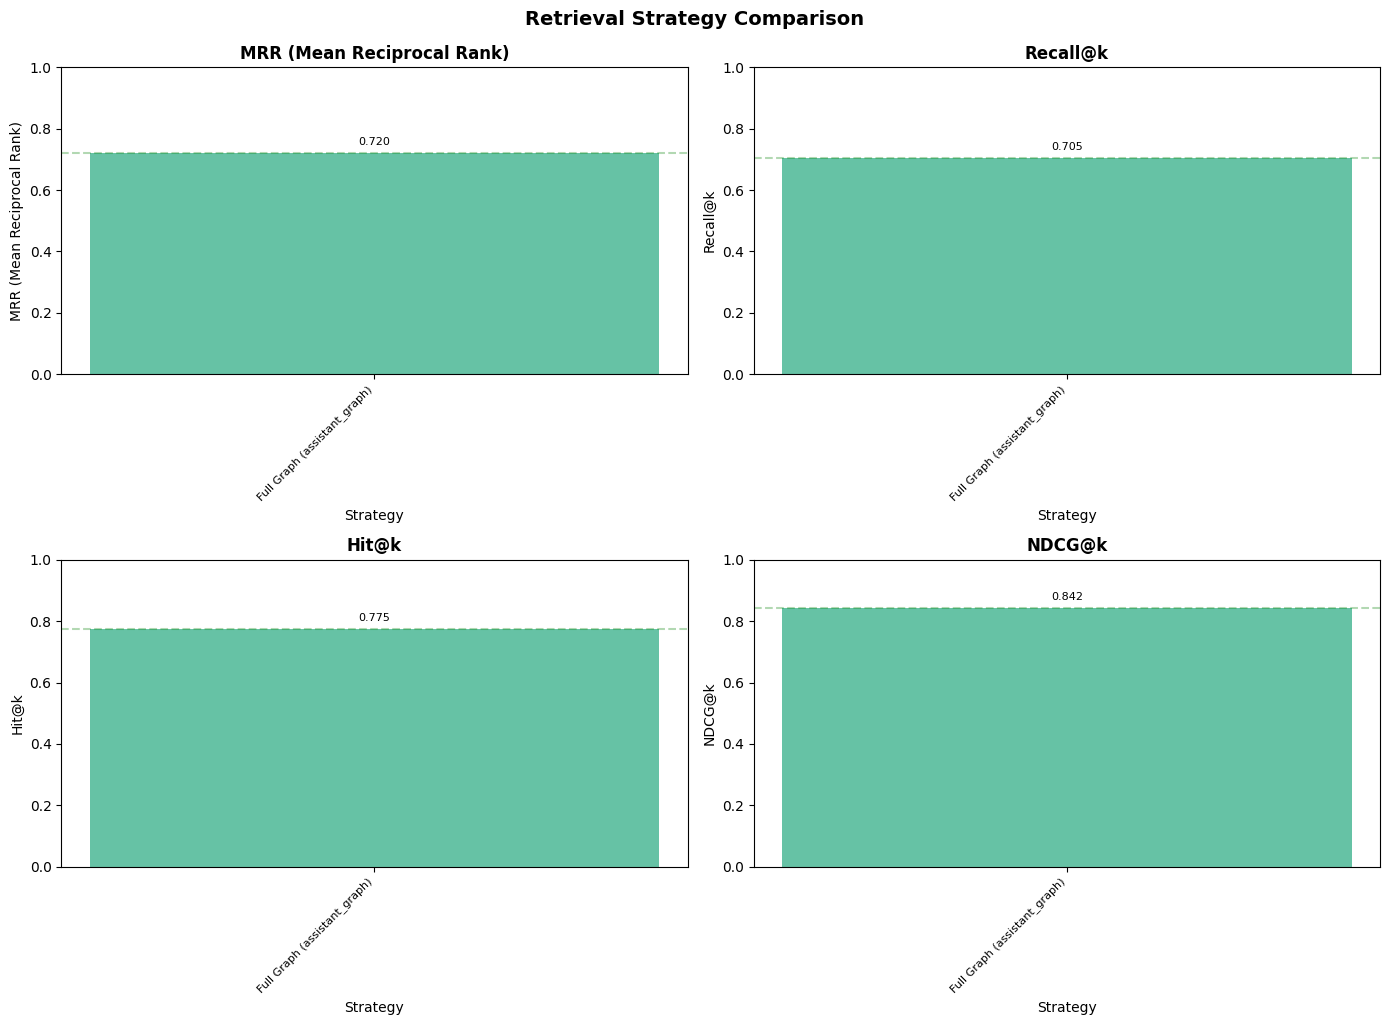


✅ Visualization complete!


In [445]:
### Visualization - Strategy Comparison

import matplotlib.pyplot as plt
import numpy as np

# Create comparison bar chart
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Metrics to plot
metrics_to_plot = [
    ("MRR (Mean Reciprocal Rank)", "mrr"),
    ("Recall@k", "recall@k"),
    ("Hit@k", "hit@k"),
    ("NDCG@k", "ndcg@k"),
]

strategies = comparison.index.tolist()
colors = plt.cm.Set2(np.linspace(0, 1, len(strategies)))

for ax, (title, metric) in zip(axes.flatten(), metrics_to_plot):
    values = comparison[metric].values
    bars = ax.bar(range(len(strategies)), values, color=colors)
    ax.set_xlabel("Strategy", fontsize=10)
    ax.set_ylabel(title, fontsize=10)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xticks(range(len(strategies)))
    ax.set_xticklabels(strategies, rotation=45, ha='right', fontsize=8)
    ax.set_ylim(0, 1)
    ax.axhline(y=values.max(), color='green', linestyle='--', alpha=0.3)

    # Add value labels on bars
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.suptitle('Retrieval Strategy Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.show()

# Radar chart for comprehensive view (if more than 2 strategies)
if len(strategies) >= 3:
    from math import pi

    # Select key metrics
    radar_metrics = ["mrr", "recall@k", "hit@k", "ndcg@k", "precision@k", "map"]

    # Number of variables
    N = len(radar_metrics)

    # Angle for each metric
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]  # complete the circle

    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

    for i, strategy in enumerate(strategies[:6]):  # Max 6 strategies for readability
        values = comparison.loc[strategy, radar_metrics].values.tolist()
        values += values[:1]  # complete the circle
        ax.plot(angles, values, 'o-', linewidth=2, label=strategy, color=colors[i])
        ax.fill(angles, values, alpha=0.1, color=colors[i])

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(radar_metrics, fontsize=10)
    ax.set_ylim(0, 1)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1))
    plt.title('Strategy Performance Radar', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

print("\n✅ Visualization complete!")

### Optimal k Analysis

Evaluate different k values to find the optimal retrieval depth for your dataset.

#### Final Performance Summary

This summary provides metrics in the same format as the baseline evaluation for fair comparison.

In [446]:
### Final Performance Summary (for comparison with Baseline)

# Auto-select top evaluated strategy (full-graph mode currently has one strategy)
best_strategy = comparison.index[0]
best_metrics = comparison.loc[best_strategy]
best_df = df_all[df_all["strategy"] == best_strategy]

print("\n" + "=" * 80)
print("📊 FULL-GRAPH EVALUATION COMPLETE")
print("=" * 80)
print(f"\nConfiguration:")
print(f"  • Evaluated Graph: {best_strategy}")
print(f"  • Embeddings: sentence-transformers/all-MiniLM-L6-v2")
print(f"  • k={EVAL_K}")
print(f"  • Total Queries: {len(eval_queries)}")
print(f"  • Strategies Tested: {len(comparison)}")
print(f"\n🎯 Graph Retrieval Metrics ({best_strategy}):")
print(f"  • Hit@k:       {best_metrics['hit@k']:.3f}")
print(f"  • Recall@k:    {best_metrics['recall@k']:.3f}")
print(f"  • Precision@k: {best_metrics['precision@k']:.3f}")
print(f"  • MRR:         {best_metrics['mrr']:.3f}")
print(f"  • MAP:         {best_metrics['map']:.3f}")
print(f"  • NDCG@k:      {best_metrics['ndcg@k']:.3f}")
print(f"\n✅ Retrieval Success Rate: {best_metrics['hit@k']*100:.1f}%")

# Optional graph execution metrics if available
if "retrieval_status" in best_df.columns:
    print("\n⚙️ Graph Execution Metrics:")
    retrieval_counts = best_df["retrieval_status"].fillna("unknown").value_counts()
    total = len(best_df) if len(best_df) else 1
    for status, count in retrieval_counts.items():
        print(f"  • retrieval_status[{status}]: {count}/{len(best_df)} ({(count/total)*100:.1f}%)")

if "generation_status" in best_df.columns:
    generation_counts = best_df["generation_status"].fillna("unknown").value_counts()
    total = len(best_df) if len(best_df) else 1
    for status, count in generation_counts.items():
        print(f"  • generation_status[{status}]: {count}/{len(best_df)} ({(count/total)*100:.1f}%)")

# Performance by difficulty
if "difficulty" in best_df.columns:
    print(f"\n📊 {best_strategy} Performance by Difficulty:")
    for difficulty in ["easy", "medium", "hard"]:
        diff_df = best_df[best_df["difficulty"] == difficulty]
        if len(diff_df) > 0:
            print(f"\n  [{difficulty.upper()}] ({len(diff_df)} queries)")
            print(f"    • Hit@k:    {diff_df['hit@k'].mean():.3f}")
            print(f"    • Recall:   {diff_df['recall@k'].mean():.3f}")
            print(f"    • MRR:      {diff_df['mrr'].mean():.3f}")

print("=" * 80)


📊 FULL-GRAPH EVALUATION COMPLETE

Configuration:
  • Evaluated Graph: Full Graph (assistant_graph)
  • Embeddings: sentence-transformers/all-MiniLM-L6-v2
  • k=10
  • Total Queries: 40
  • Strategies Tested: 1

🎯 Graph Retrieval Metrics (Full Graph (assistant_graph)):
  • Hit@k:       0.775
  • Recall@k:    0.705
  • Precision@k: 0.310
  • MRR:         0.720
  • MAP:         0.904
  • NDCG@k:      0.842

✅ Retrieval Success Rate: 77.5%

⚙️ Graph Execution Metrics:
  • retrieval_status[success]: 37/40 (92.5%)
  • retrieval_status[no_relevant_docs]: 3/40 (7.5%)
  • generation_status[error: Error code: 429 - {'error': {'message': 'Rate limi]: 26/40 (65.0%)
  • generation_status[success]: 14/40 (35.0%)

📊 Full Graph (assistant_graph) Performance by Difficulty:

  [EASY] (24 queries)
    • Hit@k:    0.750
    • Recall:   0.750
    • MRR:      0.729

  [MEDIUM] (12 queries)
    • Hit@k:    0.833
    • Recall:   0.667
    • MRR:      0.692

  [HARD] (4 queries)
    • Hit@k:    0.750
    • Re

In [447]:
### Detailed Per-Query Results

def show_detailed_results(df: pd.DataFrame, strategy_name: str):
    """Show detailed results for a specific strategy"""
    strategy_df = df[df["strategy"] == strategy_name].copy()

    print(f"\n{'='*70}")
    print(f"📋 Detailed Results: {strategy_name}")
    print(f"{'='*70}")

    for i, row in strategy_df.iterrows():
        status = "✅" if row["hit@k"] > 0 else "❌"
        difficulty = row.get('difficulty', 'N/A')
        query_type = row.get('query_type', 'N/A')
        print(f"\n{status} [{difficulty}] Query: {row['query']}")
        print(f"   Type: {query_type}")
        print(f"   Expected: {row.get('ground_truth_ids', 'N/A')}")
        print(f"   Retrieved: {row.get('retrieved_ids', 'N/A')[:5]}")
        print(f"   Metrics: MRR={row['mrr']:.2f}, Recall={row['recall@k']:.2f}, Precision={row['precision@k']:.2f}")

# Show detailed results for top evaluated strategy
best_strategy = comparison.index[0]
print_evaluation_summary(df_all[df_all["strategy"] == best_strategy], best_strategy)
show_detailed_results(df_all, best_strategy)

# Also show BM25 baseline for comparison
if "BM25 Only" in comparison.index and best_strategy != "BM25 Only":
    print("\n\n" + "="*70)
    print("📋 Baseline Comparison (BM25 Only)")
    print("="*70)
    show_detailed_results(df_all, "BM25 Only")


📊 Full Graph (assistant_graph) - EVALUATION SUMMARY

Total Queries: 40

🎯 Retrieval Metrics (averaged):
  • Hit@k:       0.775  (found at least 1 relevant)
  • Recall@k:    0.705  (completeness)
  • Precision@k: 0.310  (accuracy)
  • MRR:         0.720  (first relevant rank)
  • MAP:         0.904  (ranking quality)
  • NDCG@k:      0.842  (graded relevance)

✅ Success Rate: 77.5%

📋 Detailed Results: Full Graph (assistant_graph)

❌ [easy] Query: Show me women's black sports shoes
   Type: specific
   Expected: ['34651']
   Retrieved: ['42027', '42995', '9119', '8526', '25464']
   Metrics: MRR=0.00, Recall=0.00, Precision=0.00

✅ [easy] Query: Is the Nike Women Free Run pink sports shoe availa...
   Type: availability
   Expected: ['36137']
   Retrieved: ['36137', '6643', '32190', '36418', '40483']
   Metrics: MRR=1.00, Recall=1.00, Precision=0.17

✅ [easy] Query: Do you have ADIDAS women Ranger navy blue sports s...
   Type: specific
   Expected: ['34834']
   Retrieved: ['34834']
   